In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from tqdm import tqdm 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import torch
from torch.utils import data
import torch.nn as nn
import torch.optim as optim
import pickle
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as TorchDataset
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")


In [2]:
class Dataset(TorchDataset):
    def __init__(self, x, y, num_classes, dim):

        self.num_classes = num_classes
        self.dim = dim

        x = torch.from_numpy(x).float()      
        y = torch.from_numpy(y).long()     

        self.x = x
        self.y = y

        self.length = x.shape[0] - dim + 1  


    def __len__(self):
        return self.length

    def __getitem__(self, i):

        w = self.x[i:i+self.dim, :]         

        w = w.permute(1, 0)                

        return w, self.y[i]

In [3]:
def make_loaders_for_fold(fold,h=5,dim=10,selected_dimension=144,batch_size=256,train_dir="../data/training",test_dir="../data/testing",val_ratio=0.0):
    train_path = f"{train_dir}/Train_Dst_NoAuction_ZScore_CF_{fold}.txt"
    test_path  = f"{test_dir}/Test_Dst_NoAuction_ZScore_CF_{fold}.txt"

    dec_data = np.loadtxt(train_path)
    dec_test = np.loadtxt(test_path)

    if val_ratio is None or val_ratio <= 0.0:
        dec_train_raw = dec_data
        dec_val_raw = None
    else:
        n_cols = dec_data.shape[1]
        cut = int(n_cols * (1 - val_ratio))
        dec_train_raw = dec_data[:, :cut]
        dec_val_raw   = dec_data[:, cut:]

    y_train = dec_train_raw[-h, :].flatten()[dim-1:] - 1
    y_test  = dec_test[-h, :].flatten()[dim-1:] - 1

    X_train = dec_train_raw[:selected_dimension, :].T
    X_test  = dec_test[:selected_dimension, :].T

    if X_train.shape[0] < dim:
        raise ValueError(f"Train too short: X_train has N={X_train.shape[0]} but dim={dim}")
    if X_test.shape[0] < dim:
        raise ValueError(f"Test too short: X_test has N={X_test.shape[0]} but dim={dim}")

    ds_train = Dataset(X_train, y_train, 3, dim)
    ds_test  = Dataset(X_test,  y_test,  3, dim)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)

    if dec_val_raw is None:
        val_loader = None
    else:
        y_val = dec_val_raw[-h, :].flatten()[dim-1:] - 1
        X_val = dec_val_raw[:selected_dimension, :].T

        if X_val.shape[0] < dim:
            val_loader = None
        else:
            ds_val = Dataset(X_val, y_val, 3, dim)
            val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, y_train

In [4]:
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
def compute_class_weights(y_np):

    c0 = (y_np == 0).sum()
    c1 = (y_np == 1).sum()
    c2 = (y_np == 2).sum()
    w = torch.tensor([1e6/max(c0,1), 1e6/max(c1,1), 1e6/max(c2,1)], dtype=torch.float32, device=device)
    return w

In [26]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for X, y in loader:
        X = X.float().to(device)
        y = y.long().to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean().item()

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [25]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def eval_epoch(model, loader, criterion, return_preds=False):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true = []
    n_batches = 0

    for X, y in loader:
        X = X.float().to(device)
        y = y.long().to(device)

        logits = model(X)
        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item()
        n_batches += 1

        all_preds.append(preds.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true  = np.concatenate(all_true)

    acc = (all_preds == all_true).mean()
    macro_f1 = f1_score(all_true, all_preds, average="macro")

    avg_loss = total_loss / max(n_batches, 1)

    if return_preds:
        return avg_loss, acc, macro_f1, all_true, all_preds
    return avg_loss, acc, macro_f1


In [8]:
class MLPBaseline(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),              
            nn.Linear(144*10, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class CNNTimeBaseline(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=144, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        
        z = self.features(x)    
        z = z.mean(dim=2)             
        out = self.classifier(z)      
        return out

In [ ]:
class TABLLayer(nn.Module):
    def __init__(self, in_dim, in_time, out_dim, out_time, activation=F.relu):
        super().__init__()
        self.in_dim = in_dim
        self.in_time = in_time
        self.out_dim = out_dim
        self.out_time = out_time
        self.activation = activation

        self.W1 = nn.Parameter(torch.empty(out_dim, in_dim))
        self.W  = nn.Parameter(torch.empty(in_time, in_time))
        self.W2 = nn.Parameter(torch.empty(in_time, out_time))
        self.B  = nn.Parameter(torch.zeros(out_dim, out_time))
        self.lambda_param = nn.Parameter(torch.tensor(0.5))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W1)
        nn.init.xavier_uniform_(self.W2)
        with torch.no_grad():
            self.W.fill_(1.0 / max(self.in_time, 1))

    def forward(self, x, return_attention=False):
        x_bar = torch.matmul(self.W1, x)  

        eye = torch.eye(self.in_time, device=self.W.device, dtype=self.W.dtype)
        W_eff = self.W * (1.0 - eye) + (1.0 / max(self.in_time, 1)) * eye

        E = torch.matmul(x_bar, W_eff)  
        A = torch.softmax(E, dim=2)  

        lam = torch.clamp(self.lambda_param, 0.0, 1.0)
        x_tilde = lam * (x_bar * A) + (1.0 - lam) * x_bar

        Y = torch.matmul(x_tilde, self.W2) + self.B 
        if self.activation is not None:
            Y = self.activation(Y)

        if return_attention:
            return Y, A
        return Y
    
class TABLClassifier(nn.Module):
    def __init__(self, num_classes=3, in_dim=144, in_time=10, hidden_dim=64, hidden_time=5, dropout=0.1):
        super().__init__()
        self.in_time = in_time
        self.tabl = TABLLayer(in_dim=in_dim, in_time=in_time, out_dim=hidden_dim, out_time=hidden_time, activation=F.relu)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * hidden_time, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x, return_attention=False):
        if return_attention:
            z, A = self.tabl(x, return_attention=True)
            logits = self.head(z)
            return logits, A
        z = self.tabl(x)
        return self.head(z)


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class BilinearNormalization(nn.Module):

    def __init__(self, D: int, T: int, eps: float = 1e-5):
        super().__init__()
        self.D = D
        self.T = T
        self.eps = eps


        self.gamma_t = nn.Parameter(torch.ones(D))
        self.beta_t  = nn.Parameter(torch.zeros(D))

 
        self.gamma_f = nn.Parameter(torch.ones(T))
        self.beta_f  = nn.Parameter(torch.zeros(T))

        self._w_t = nn.Parameter(torch.tensor(0.0))
        self._w_f = nn.Parameter(torch.tensor(0.0))

    @property
    def w_t(self):
        return F.softplus(self._w_t)

    @property
    def w_f(self):
        return F.softplus(self._w_f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, D, T = x.shape
        assert D == self.D and T == self.T, f"Expected (B,{self.D},{self.T}) got {x.shape}"


        mu_t = x.mean(dim=2, keepdim=True) 
        std_t = x.std(dim=2, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_t = (x - mu_t) / std_t
        x_t = x_t * self.gamma_t.view(1, D, 1) + self.beta_t.view(1, D, 1)


        mu_f = x.mean(dim=1, keepdim=True) 
        std_f = x.std(dim=1, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_f = (x - mu_f) / std_f
        x_f = x_f * self.gamma_f.view(1, 1, T) + self.beta_f.view(1, 1, T)

        return self.w_t * x_t + self.w_f * x_f


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, T: int, C: int):
        super().__init__()
        self.T = T
        self.C = C
        self.register_buffer("pe", torch.empty(0), persistent=False)

    def _build(self, device, dtype):
        T, C = self.T, self.C
        pe = torch.zeros(T, C, device=device, dtype=dtype)  # (T, C)
        position = torch.arange(0, T, device=device, dtype=dtype).unsqueeze(1)  # (T, 1)
        div_term = torch.exp(torch.arange(0, C, 2, device=device, dtype=dtype) * (-math.log(10000.0) / C))
        pe[:, 0::2] = torch.sin(position * div_term)
        if C % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0) 

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.pe.numel() == 0 or self.pe.shape != (1, self.T, self.C) or self.pe.device != x.device or self.pe.dtype != x.dtype:
            self._build(x.device, x.dtype)
        return x + self.pe


class MLPLOBMixer(nn.Module):

    def __init__(self, T: int, C: int, mlp_time: int = 64, mlp_feat: int = 256, dropout: float = 0.1):
        super().__init__()
        self.ln_time = nn.LayerNorm(T)
        self.fc_time1 = nn.Linear(T, mlp_time)
        self.fc_time2 = nn.Linear(mlp_time, T)

        self.ln_feat = nn.LayerNorm(C)
        self.fc_feat1 = nn.Linear(C, mlp_feat)
        self.fc_feat2 = nn.Linear(mlp_feat, C)

        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        y = x.transpose(1, 2)        
        y = self.ln_time(y)
        y = self.fc_time2(self.drop(F.gelu(self.fc_time1(y))))
        y = self.drop(y).transpose(1, 2) 
        x = x + y

        y = self.ln_feat(x)
        y = self.fc_feat2(self.drop(F.gelu(self.fc_feat1(y))))
        y = self.drop(y)
        x = x + y
        return x


class DualAttentionBlock(nn.Module):

    def __init__(
        self,
        input_dim: int,
        time_steps: int,
        d_model: int = 144,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.d_feat_attn = d_feat_attn

        self.ln_time = nn.LayerNorm(d_model)
        self.attn_time = nn.MultiheadAttention(d_model, n_heads_time, dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)

        self.proj_T_to_feat = nn.Linear(time_steps, d_feat_attn)
        self.proj_feat_to_T = nn.Linear(d_feat_attn, time_steps)

        self.ln_feat = nn.LayerNorm(d_feat_attn)
        self.attn_feat = nn.MultiheadAttention(d_feat_attn, n_heads_feat, dropout=dropout, batch_first=True)

        self.mixer = MLPLOBMixer(
            T=time_steps,
            C=d_model,
            mlp_time=max(16, time_steps * 4),
            mlp_feat=max(128, d_model * 2),
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):

        y = self.ln_time(x)
        y, attn_t = self.attn_time(
            y, y, y,
            need_weights=return_attn,
            average_attn_weights=False 
        )
        x = x + self.drop(y)

        x_feat = x.transpose(1, 2)            
        x_feat = self.proj_T_to_feat(x_feat) 

        y = self.ln_feat(x_feat)
        y, attn_f = self.attn_feat(
            y, y, y,
            need_weights=return_attn,
            average_attn_weights=False  
        )
        x_feat = x_feat + self.drop(y)

        x_feat = self.proj_feat_to_T(x_feat)   
        x = x_feat.transpose(1, 2)           
        x = self.mixer(x)

        if return_attn:
            return x, attn_t, attn_f
        return x



class TLOBClassifier(nn.Module):
    def __init__(
        self,
        num_classes: int = 3,
        input_dim: int = 144,
        time_steps: int = 10,
        d_model: int = 144,
        n_layers: int = 2,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
        use_bin: bool = True,
        use_pos_enc: bool = True,
        cls_pool: str = "last", 
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.cls_pool = cls_pool

        self.bin = BilinearNormalization(D=input_dim, T=time_steps) if use_bin else nn.Identity()
        self.proj_in = nn.Linear(input_dim, d_model) if d_model != input_dim else nn.Identity()
        self.pos = SinusoidalPositionalEncoding(T=time_steps, C=d_model) if use_pos_enc else nn.Identity()

        self.blocks = nn.ModuleList([
            DualAttentionBlock(
                input_dim=input_dim,
                time_steps=time_steps,
                d_model=d_model,
                n_heads_time=n_heads_time,
                d_feat_attn=d_feat_attn,
                n_heads_feat=n_heads_feat,
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        x = self.bin(x)             
        x = x.transpose(1, 2)      
        x = self.proj_in(x)        
        x = self.pos(x)           

        attn_time_all = []
        attn_feat_all = []

        for blk in self.blocks:
            if return_attn:
                x, attn_t, attn_f = blk(x, return_attn=True)
                attn_time_all.append(attn_t)
                attn_feat_all.append(attn_f)
            else:
                x = blk(x)

        x = self.ln_out(x)

        h = x.mean(dim=1) if self.cls_pool == "mean" else x[:, -1, :]

        logits = self.head(h)

        if return_attn:

            return logits, attn_time_all, attn_feat_all
        return logits


In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for X, y in loader:
        X = X.float().to(device)
        y = y.long().to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
def fit(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    best_val_f1 = -1.0
    best_state = None

    for epoch in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_f1 = eval_model(model, val_loader, criterion)

        print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_acc={va_acc:.4f} | val_macroF1={va_f1:.4f}")

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

In [ ]:
@torch.no_grad()
def collect_avg_tabl_attention_per_class(model, loader, num_classes=3, device="cuda"):
    model.eval()
    T = model.in_time  
    sum_att = np.zeros((num_classes, T), dtype=np.float64)
    cnt     = np.zeros((num_classes,), dtype=np.int64)

    for X, y in loader:
        X = X.float().to(device)
        y = y.long().to(device)

        logits, A = model(X, return_attention=True)  
        A_time = A.mean(dim=1)                    

        A_np = A_time.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        for c in range(num_classes):
            m = (y_np == c)
            if np.any(m):
                sum_att[c] += A_np[m].sum(axis=0)
                cnt[c]     += m.sum()

    avg_att = sum_att / np.maximum(cnt[:, None], 1)
    return avg_att, cnt


In [ ]:
import numpy as np
import torch

@torch.no_grad()
def collect_avg_time_attention_per_class(
    model, loader, num_classes=3, device="cuda", layer="last"
):
    model.eval()

    T = model.time_steps
    sum_att = np.zeros((num_classes, T), dtype=np.float64)
    cnt     = np.zeros((num_classes,), dtype=np.int64)

    for X, y in loader:
        X = X.float().to(device)
        y = y.long().to(device)

        logits, attn_time_all, _ = model(X, return_attn=True)

        if layer == "last":
            A = attn_time_all[-1]      
        else:

            A = torch.stack(attn_time_all, dim=0).mean(dim=0) 

        A = A.mean(dim=1)    
        A = A.mean(dim=1)   

        A_np = A.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        for c in range(num_classes):
            m = (y_np == c)
            if np.any(m):
                sum_att[c] += A_np[m].sum(axis=0)
                cnt[c]     += m.sum()

    avg_att = sum_att / np.maximum(cnt[:, None], 1)
    return avg_att, cnt

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_average_attention_history(att_history, title="Average Attention over epochs"):

    H = np.stack(att_history, axis=0)  
    E, C, T = H.shape
    class_names = ["decrease", "stationary", "increase"]

    fig, axes = plt.subplots(1, C, figsize=(15, 4.6), sharey=True)

    for c in range(C):
        ax = axes[c]
        for t in range(T):
            label = f"t-{(T-1-t)}" if t != T-1 else "t"
            ax.plot(range(1, E+1), H[:, c, t], label=label)

        ax.set_title(f"Movement: {class_names[c]}")
        ax.set_xlabel("Epoch")
        ax.set_xlim(1, E)
        ax.grid(True, alpha=0.2)

    axes[0].set_ylabel("Average Attention (time)")
    axes[-1].legend(loc="best", ncol=2, fontsize=8)
    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.tight_layout()
    plt.show()


In [ ]:
def run_walk_forward_cv(
    model_builder, model_name,
    epochs=20, lr=1e-3, batch_size=256, h=5, dim=10, val_ratio=0.0,
    track_attention=False, attention_on='test', attention_every=1,
    attention_collector=None,        
    plot_attention=False,              
    plot_attention_title=None        
):
    set_seed(42)
    fold_results = []

    print(f"\n==============================")
    print(f"MODEL (Setup1 walk-forward): {model_name}")
    print(f"==============================\n")

    for fold in range(1, 10):
        print(f"\n===== Fold {fold}: Train days 1..{fold} | Test day {fold+1} =====")

        train_loader, val_loader, test_loader, y_train = make_loaders_for_fold(
            fold=fold, h=h, dim=dim, batch_size=batch_size, val_ratio=val_ratio
        )

        weights = compute_class_weights(y_train.astype(np.int64))
        weights = weights / weights.mean()
        criterion = nn.CrossEntropyLoss(weight=weights)

        model = model_builder().to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        best_state = None
        best_val_f1 = -1.0

        att_history = []
        att_counts  = []

        for epoch in range(1, epochs+1):
            tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)

            if val_loader is not None:
                va_loss, va_acc, va_f1, y_true, y_pred = eval_epoch(model, val_loader, criterion, return_preds=True)
                print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} acc {tr_acc:.4f} | val_loss {va_loss:.4f} acc {va_acc:.4f} macroF1 {va_f1:.4f}")
                if va_f1 > best_val_f1:
                    best_val_f1 = va_f1
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} acc {tr_acc:.4f}")

            if track_attention and (attention_collector is not None) and (epoch % attention_every == 0):
                att_loader = test_loader if attention_on == 'test' else train_loader
                try:
                    avg_att, cnt = attention_collector(model, att_loader, num_classes=3, device=device)
                    att_history.append(avg_att)
                    att_counts.append(cnt)
                except Exception as e:
                    if epoch == 1 and fold == 1:
                        print(f"[warn] attention tracking skipped: {e}")

        if plot_attention and track_attention and len(att_history) > 1:
            title = plot_attention_title or f"{model_name} — Avg attention ({attention_on}) | fold {fold}"
            plot_average_attention_history(att_history, title=title)

        if best_state is not None:
            model.load_state_dict(best_state)

        te_loss, te_acc, te_f1, y_true, y_pred = eval_epoch(model, test_loader, criterion, return_preds=True)
        print(f"Fold {fold} TEST | loss {te_loss:.4f} acc {te_acc:.4f} macroF1 {te_f1:.4f}")

        fold_results.append({
            "fold": fold,
            "test_loss": te_loss,
            "test_acc": te_acc,
            "test_macroF1": te_f1,
            "y_true": y_true,
            "y_pred": y_pred,
        })

    accs = [r["test_acc"] for r in fold_results]
    f1s  = [r["test_macroF1"] for r in fold_results]

    print(f"\n===== WALK-FORWARD SUMMARY: {model_name} =====")
    print(f"Test Acc    mean={np.mean(accs):.4f} std={np.std(accs, ddof=0):.4f}")
    print(f"Test MacroF1 mean={np.mean(f1s):.4f} std={np.std(f1s, ddof=0):.4f}")

    return fold_results

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(self, num_classes=3, hidden_size=128, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=144,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1] 
        return self.head(h_last)

In [15]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.res(x)

class TCNClassifier(nn.Module):
    def __init__(self, num_classes=3, dropout=0.2):
        super().__init__()
        self.tcn = nn.Sequential(
            TCNBlock(144, 128, kernel_size=3, dilation=1, dropout=dropout),
            TCNBlock(128, 128, kernel_size=3, dilation=2, dropout=dropout),
            TCNBlock(128, 128, kernel_size=3, dilation=4, dropout=dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        z = self.tcn(x)   
        z = z.mean(dim=2)      
        return self.head(z)

In [16]:
def summarize_cv(fold_results, model_name):
    df = pd.DataFrame(fold_results)
    summary = {
        "model": model_name,
        "acc_mean": df["test_acc"].mean(),
        "acc_std": df["test_acc"].std(ddof=0),
        "f1_mean": df["test_macroF1"].mean(),
        "f1_std": df["test_macroF1"].std(ddof=0),
    }
    return df, summary

In [66]:
mlp_results = run_walk_forward_cv(
    model_builder=lambda: MLPBaseline(num_classes=3),
    model_name="MLP Baseline",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1 
)


MODEL (Setup1 walk-forward): MLP Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0044 acc 0.5229 | val_loss 0.9738 acc 0.4261 macroF1 0.4263
Epoch 002 | tr_loss 0.9016 acc 0.6018 | val_loss 0.9327 acc 0.5564 macroF1 0.5261
Epoch 003 | tr_loss 0.8475 acc 0.6300 | val_loss 0.9330 acc 0.5734 macroF1 0.5345
Epoch 004 | tr_loss 0.8068 acc 0.6482 | val_loss 0.9206 acc 0.5671 macroF1 0.5360
Epoch 005 | tr_loss 0.7669 acc 0.6644 | val_loss 0.9711 acc 0.6498 macroF1 0.5600
Epoch 006 | tr_loss 0.7268 acc 0.6849 | val_loss 0.9144 acc 0.5983 macroF1 0.5588
Epoch 007 | tr_loss 0.7014 acc 0.6927 | val_loss 0.9268 acc 0.5164 macroF1 0.5078
Epoch 008 | tr_loss 0.6699 acc 0.7082 | val_loss 0.9676 acc 0.5508 macroF1 0.5222
Epoch 009 | tr_loss 0.6396 acc 0.7176 | val_loss 0.9381 acc 0.4885 macroF1 0.4847
Epoch 010 | tr_loss 0.6165 acc 0.7277 | val_loss 0.9557 acc 0.5529 macroF1 0.5283
Epoch 011 | tr_loss 0.5886 acc 0.7392 | val_loss 0.9663 acc 0.4968 macroF1 0.4910
Epoc

In [67]:
cnn_results = run_walk_forward_cv(
    model_builder=lambda: CNNTimeBaseline(num_classes=3),
    model_name="CNN Time Baseline",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1 
)


MODEL (Setup1 walk-forward): CNN Time Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0266 acc 0.5053 | val_loss 1.0193 acc 0.4573 macroF1 0.4401
Epoch 002 | tr_loss 0.9681 acc 0.5322 | val_loss 1.0188 acc 0.4377 macroF1 0.4115
Epoch 003 | tr_loss 0.9095 acc 0.5914 | val_loss 0.9378 acc 0.5590 macroF1 0.5274
Epoch 004 | tr_loss 0.8460 acc 0.6361 | val_loss 0.8909 acc 0.5810 macroF1 0.5544
Epoch 005 | tr_loss 0.7851 acc 0.6681 | val_loss 0.8815 acc 0.6396 macroF1 0.5879
Epoch 006 | tr_loss 0.7351 acc 0.6901 | val_loss 0.9208 acc 0.6708 macroF1 0.6055
Epoch 007 | tr_loss 0.7020 acc 0.7054 | val_loss 0.8520 acc 0.6072 macroF1 0.5793
Epoch 008 | tr_loss 0.6694 acc 0.7221 | val_loss 0.8485 acc 0.6198 macroF1 0.5879
Epoch 009 | tr_loss 0.6412 acc 0.7338 | val_loss 0.8438 acc 0.6089 macroF1 0.5820
Epoch 010 | tr_loss 0.6178 acc 0.7447 | val_loss 0.8706 acc 0.6094 macroF1 0.5796
Epoch 011 | tr_loss 0.5926 acc 0.7574 | val_loss 0.9034 acc 0.6434 macroF1 0.5961

In [68]:
lstm_results = run_walk_forward_cv(
    model_builder=lambda: LSTMClassifier(num_classes=3, hidden_size=128),
    model_name="LSTM",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)


MODEL (Setup1 walk-forward): LSTM


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.9952 acc 0.5350 | val_loss 0.9902 acc 0.4157 macroF1 0.4174
Epoch 002 | tr_loss 0.8440 acc 0.6346 | val_loss 0.9285 acc 0.5615 macroF1 0.5317
Epoch 003 | tr_loss 0.7492 acc 0.6831 | val_loss 0.8768 acc 0.5643 macroF1 0.5445
Epoch 004 | tr_loss 0.6858 acc 0.7097 | val_loss 0.8649 acc 0.6264 macroF1 0.5833
Epoch 005 | tr_loss 0.6299 acc 0.7343 | val_loss 0.8636 acc 0.6026 macroF1 0.5698
Epoch 006 | tr_loss 0.5717 acc 0.7557 | val_loss 0.8809 acc 0.5694 macroF1 0.5477
Epoch 007 | tr_loss 0.5193 acc 0.7773 | val_loss 0.8950 acc 0.5694 macroF1 0.5520
Epoch 008 | tr_loss 0.4697 acc 0.7976 | val_loss 0.9369 acc 0.6104 macroF1 0.5794
Epoch 009 | tr_loss 0.4187 acc 0.8150 | val_loss 0.9987 acc 0.6290 macroF1 0.5916
Epoch 010 | tr_loss 0.3814 acc 0.8275 | val_loss 1.0326 acc 0.6498 macroF1 0.6002
Epoch 011 | tr_loss 0.3369 acc 0.8482 | val_loss 1.0005 acc 0.6153 macroF1 0.5835
Epoch 012 | 

In [70]:
tcn_results = run_walk_forward_cv(
    model_builder=lambda: TCNClassifier(num_classes=3),
    model_name="TCN",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)



MODEL (Setup1 walk-forward): TCN


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0108 acc 0.5143 | val_loss 0.9675 acc 0.5308 macroF1 0.5016
Epoch 002 | tr_loss 0.8947 acc 0.6072 | val_loss 0.9122 acc 0.5744 macroF1 0.5448
Epoch 003 | tr_loss 0.8263 acc 0.6456 | val_loss 0.8821 acc 0.5298 macroF1 0.5229
Epoch 004 | tr_loss 0.7733 acc 0.6707 | val_loss 0.8743 acc 0.5864 macroF1 0.5598
Epoch 005 | tr_loss 0.7435 acc 0.6863 | val_loss 0.8602 acc 0.6520 macroF1 0.6066
Epoch 006 | tr_loss 0.7114 acc 0.6984 | val_loss 0.8635 acc 0.5914 macroF1 0.5635
Epoch 007 | tr_loss 0.6854 acc 0.7084 | val_loss 0.8528 acc 0.6214 macroF1 0.5901
Epoch 008 | tr_loss 0.6565 acc 0.7230 | val_loss 0.8999 acc 0.6635 macroF1 0.6172
Epoch 009 | tr_loss 0.6347 acc 0.7329 | val_loss 0.8741 acc 0.6439 macroF1 0.6007
Epoch 010 | tr_loss 0.6153 acc 0.7370 | val_loss 0.8560 acc 0.6115 macroF1 0.5874
Epoch 011 | tr_loss 0.5917 acc 0.7498 | val_loss 0.8527 acc 0.6460 macroF1 0.6070
Epoch 012 | t


MODEL (Setup1 walk-forward): TABL


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0361 acc 0.5176 | val_loss 1.0035 acc 0.5237 macroF1 0.4819
Epoch 002 | tr_loss 0.9286 acc 0.5967 | val_loss 0.9463 acc 0.5219 macroF1 0.4906
Epoch 003 | tr_loss 0.8527 acc 0.6363 | val_loss 0.8951 acc 0.5980 macroF1 0.5618
Epoch 004 | tr_loss 0.7969 acc 0.6694 | val_loss 0.8695 acc 0.6036 macroF1 0.5667
Epoch 005 | tr_loss 0.7578 acc 0.6878 | val_loss 0.8487 acc 0.5884 macroF1 0.5660
Epoch 006 | tr_loss 0.7272 acc 0.7029 | val_loss 0.8345 acc 0.6072 macroF1 0.5799
Epoch 007 | tr_loss 0.6942 acc 0.7200 | val_loss 0.8361 acc 0.5765 macroF1 0.5607
Epoch 008 | tr_loss 0.6728 acc 0.7310 | val_loss 0.8157 acc 0.6594 macroF1 0.6209
Epoch 009 | tr_loss 0.6446 acc 0.7495 | val_loss 0.7991 acc 0.6924 macroF1 0.6465
Epoch 010 | tr_loss 0.6200 acc 0.7577 | val_loss 0.7803 acc 0.6929 macroF1 0.6506
Epoch 011 | tr_loss 0.6016 acc 0.7678 | val_loss 0.7703 acc 0.6858 macroF1 0.6473
Epoch 012 | 

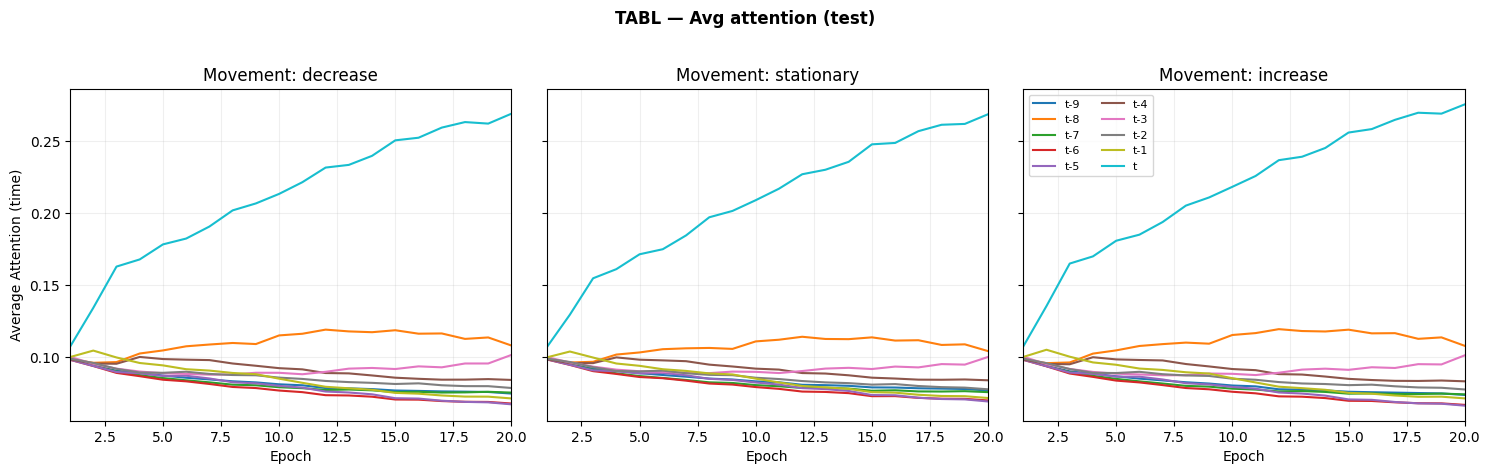

Fold 1 TEST | loss 0.6989 acc 0.7421 macroF1 0.6964

===== Fold 2: Train days 1..2 | Test day 3 =====
Epoch 001 | tr_loss 0.9815 acc 0.5546 | val_loss 0.9090 acc 0.6104 macroF1 0.5390
Epoch 002 | tr_loss 0.8416 acc 0.6427 | val_loss 0.8051 acc 0.6901 macroF1 0.6167
Epoch 003 | tr_loss 0.7528 acc 0.6924 | val_loss 0.7191 acc 0.7300 macroF1 0.6662
Epoch 004 | tr_loss 0.6937 acc 0.7348 | val_loss 0.6624 acc 0.7454 macroF1 0.6857
Epoch 005 | tr_loss 0.6490 acc 0.7608 | val_loss 0.6251 acc 0.7867 macroF1 0.7230
Epoch 006 | tr_loss 0.6223 acc 0.7721 | val_loss 0.6122 acc 0.7822 macroF1 0.7201
Epoch 007 | tr_loss 0.6002 acc 0.7781 | val_loss 0.5935 acc 0.7849 macroF1 0.7248
Epoch 008 | tr_loss 0.5816 acc 0.7850 | val_loss 0.5835 acc 0.8036 macroF1 0.7427
Epoch 009 | tr_loss 0.5681 acc 0.7865 | val_loss 0.5996 acc 0.7956 macroF1 0.7315
Epoch 010 | tr_loss 0.5569 acc 0.7898 | val_loss 0.5841 acc 0.7795 macroF1 0.7236
Epoch 011 | tr_loss 0.5443 acc 0.7933 | val_loss 0.5850 acc 0.7902 macroF1 0.7

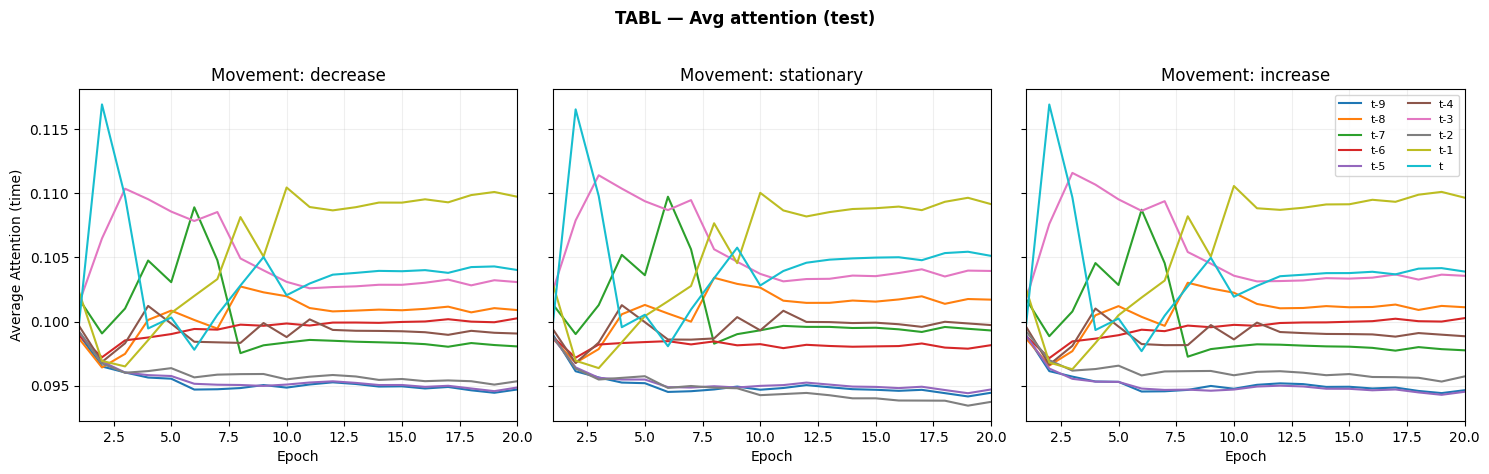

Fold 2 TEST | loss 0.5328 acc 0.8076 macroF1 0.7566

===== Fold 3: Train days 1..3 | Test day 4 =====
Epoch 001 | tr_loss 0.9344 acc 0.5874 | val_loss 0.7926 acc 0.6848 macroF1 0.6020
Epoch 002 | tr_loss 0.7588 acc 0.6949 | val_loss 0.6509 acc 0.7813 macroF1 0.6910
Epoch 003 | tr_loss 0.6747 acc 0.7501 | val_loss 0.5959 acc 0.8189 macroF1 0.7291
Epoch 004 | tr_loss 0.6332 acc 0.7726 | val_loss 0.5687 acc 0.8165 macroF1 0.7344
Epoch 005 | tr_loss 0.6063 acc 0.7802 | val_loss 0.5603 acc 0.8101 macroF1 0.7365
Epoch 006 | tr_loss 0.5874 acc 0.7855 | val_loss 0.5443 acc 0.8240 macroF1 0.7482
Epoch 007 | tr_loss 0.5713 acc 0.7887 | val_loss 0.5344 acc 0.8226 macroF1 0.7523
Epoch 008 | tr_loss 0.5597 acc 0.7911 | val_loss 0.5282 acc 0.8230 macroF1 0.7553
Epoch 009 | tr_loss 0.5487 acc 0.7936 | val_loss 0.5207 acc 0.8312 macroF1 0.7629
Epoch 010 | tr_loss 0.5348 acc 0.7976 | val_loss 0.5068 acc 0.8263 macroF1 0.7623
Epoch 011 | tr_loss 0.5246 acc 0.8002 | val_loss 0.5017 acc 0.8299 macroF1 0.7

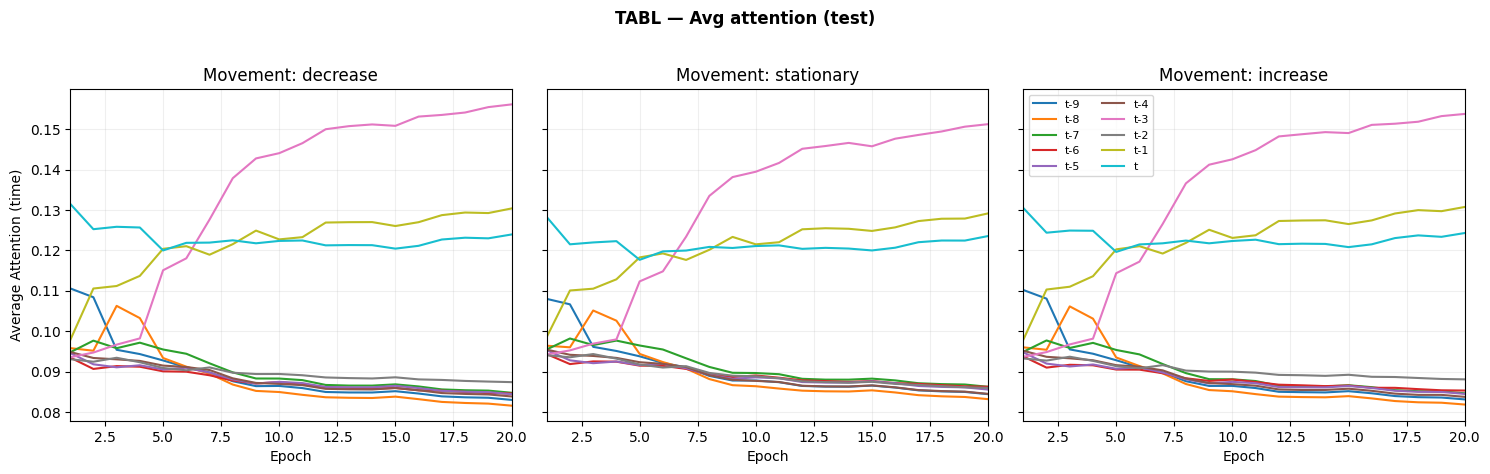

Fold 3 TEST | loss 0.5457 acc 0.7912 macroF1 0.7550

===== Fold 4: Train days 1..4 | Test day 5 =====
Epoch 001 | tr_loss 0.9205 acc 0.5992 | val_loss 0.8309 acc 0.6648 macroF1 0.5912
Epoch 002 | tr_loss 0.7403 acc 0.7087 | val_loss 0.7216 acc 0.7339 macroF1 0.6559
Epoch 003 | tr_loss 0.6588 acc 0.7584 | val_loss 0.6947 acc 0.7314 macroF1 0.6636
Epoch 004 | tr_loss 0.6176 acc 0.7749 | val_loss 0.6322 acc 0.7793 macroF1 0.7064
Epoch 005 | tr_loss 0.5938 acc 0.7813 | val_loss 0.6174 acc 0.7871 macroF1 0.7179
Epoch 006 | tr_loss 0.5758 acc 0.7866 | val_loss 0.6024 acc 0.7882 macroF1 0.7241
Epoch 007 | tr_loss 0.5611 acc 0.7910 | val_loss 0.5916 acc 0.7957 macroF1 0.7332
Epoch 008 | tr_loss 0.5483 acc 0.7929 | val_loss 0.5731 acc 0.8046 macroF1 0.7457
Epoch 009 | tr_loss 0.5371 acc 0.7971 | val_loss 0.5995 acc 0.8049 macroF1 0.7472
Epoch 010 | tr_loss 0.5277 acc 0.7996 | val_loss 0.5694 acc 0.8038 macroF1 0.7514
Epoch 011 | tr_loss 0.5223 acc 0.7992 | val_loss 0.5669 acc 0.8060 macroF1 0.7

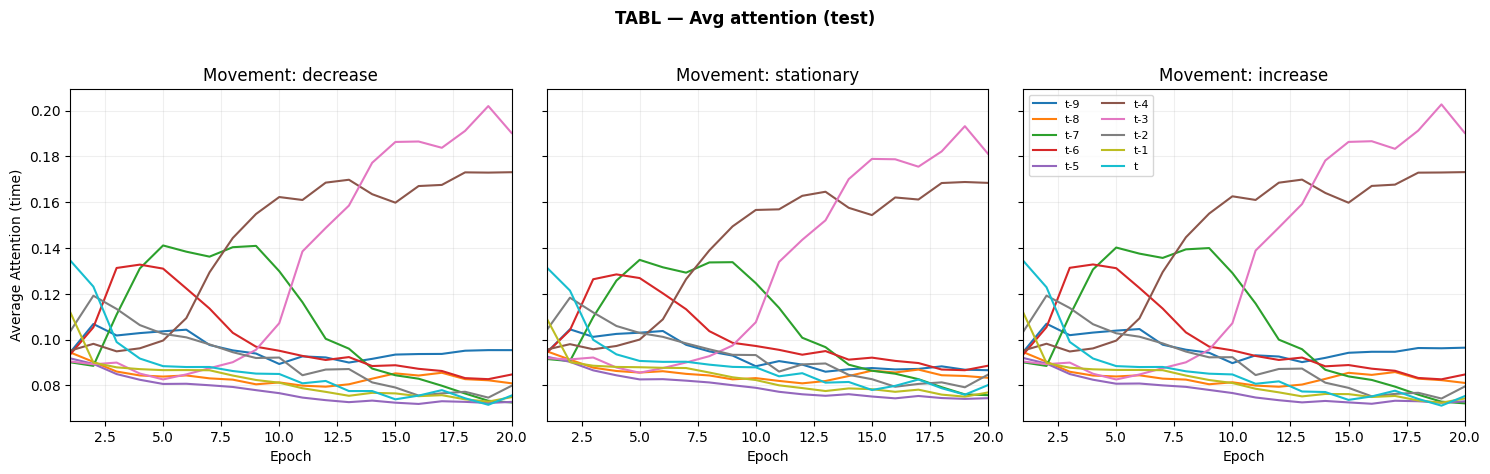

Fold 4 TEST | loss 0.5158 acc 0.7903 macroF1 0.7634

===== Fold 5: Train days 1..5 | Test day 6 =====
Epoch 001 | tr_loss 0.9192 acc 0.5949 | val_loss 0.8689 acc 0.5643 macroF1 0.5454
Epoch 002 | tr_loss 0.7587 acc 0.6923 | val_loss 0.7635 acc 0.6735 macroF1 0.6352
Epoch 003 | tr_loss 0.6728 acc 0.7485 | val_loss 0.6865 acc 0.7300 macroF1 0.6837
Epoch 004 | tr_loss 0.6297 acc 0.7706 | val_loss 0.6439 acc 0.7533 macroF1 0.7075
Epoch 005 | tr_loss 0.6003 acc 0.7803 | val_loss 0.6184 acc 0.7638 macroF1 0.7198
Epoch 006 | tr_loss 0.5779 acc 0.7864 | val_loss 0.6044 acc 0.7643 macroF1 0.7240
Epoch 007 | tr_loss 0.5561 acc 0.7913 | val_loss 0.5776 acc 0.7688 macroF1 0.7345
Epoch 008 | tr_loss 0.5418 acc 0.7942 | val_loss 0.5664 acc 0.7733 macroF1 0.7392
Epoch 009 | tr_loss 0.5272 acc 0.7983 | val_loss 0.5625 acc 0.7674 macroF1 0.7365
Epoch 010 | tr_loss 0.5160 acc 0.8012 | val_loss 0.5427 acc 0.7775 macroF1 0.7477
Epoch 011 | tr_loss 0.5066 acc 0.8023 | val_loss 0.5370 acc 0.7813 macroF1 0.7

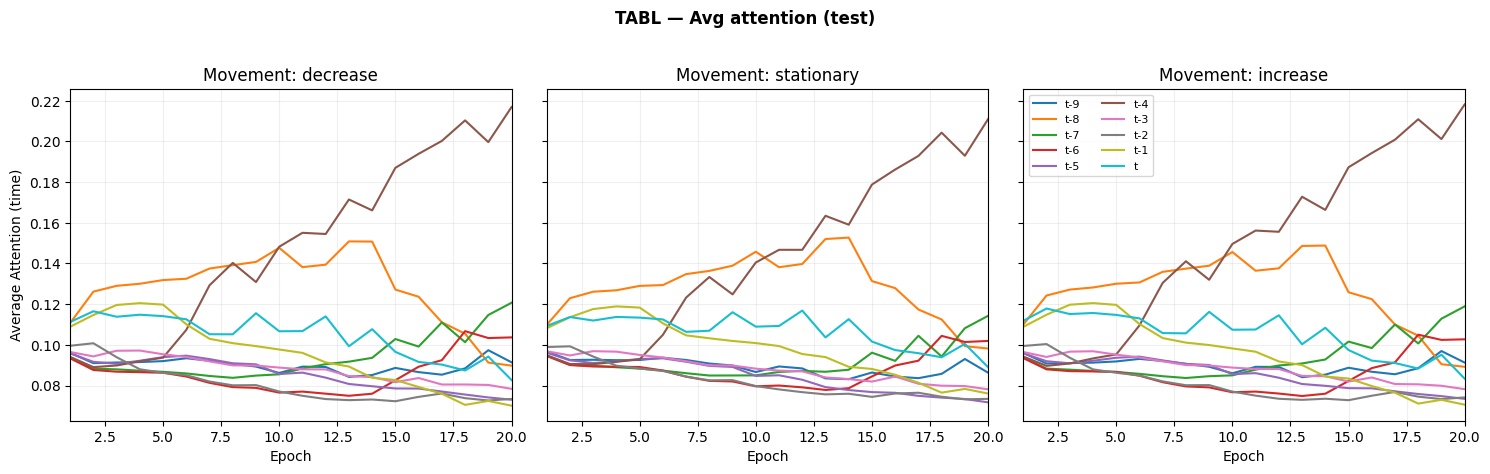

Fold 5 TEST | loss 0.4760 acc 0.8061 macroF1 0.7723

===== Fold 6: Train days 1..6 | Test day 7 =====
Epoch 001 | tr_loss 0.9033 acc 0.5954 | val_loss 0.7744 acc 0.6888 macroF1 0.6188
Epoch 002 | tr_loss 0.7078 acc 0.7228 | val_loss 0.6180 acc 0.7788 macroF1 0.7096
Epoch 003 | tr_loss 0.6210 acc 0.7726 | val_loss 0.5691 acc 0.7927 macroF1 0.7302
Epoch 004 | tr_loss 0.5853 acc 0.7834 | val_loss 0.5555 acc 0.7903 macroF1 0.7304
Epoch 005 | tr_loss 0.5635 acc 0.7894 | val_loss 0.5218 acc 0.8019 macroF1 0.7485
Epoch 006 | tr_loss 0.5430 acc 0.7935 | val_loss 0.5084 acc 0.8022 macroF1 0.7528
Epoch 007 | tr_loss 0.5279 acc 0.7980 | val_loss 0.4977 acc 0.8031 macroF1 0.7551
Epoch 008 | tr_loss 0.5137 acc 0.8004 | val_loss 0.4978 acc 0.8008 macroF1 0.7552
Epoch 009 | tr_loss 0.5071 acc 0.8015 | val_loss 0.4828 acc 0.8066 macroF1 0.7601
Epoch 010 | tr_loss 0.4998 acc 0.8032 | val_loss 0.4798 acc 0.8043 macroF1 0.7598
Epoch 011 | tr_loss 0.4927 acc 0.8043 | val_loss 0.4802 acc 0.8002 macroF1 0.7

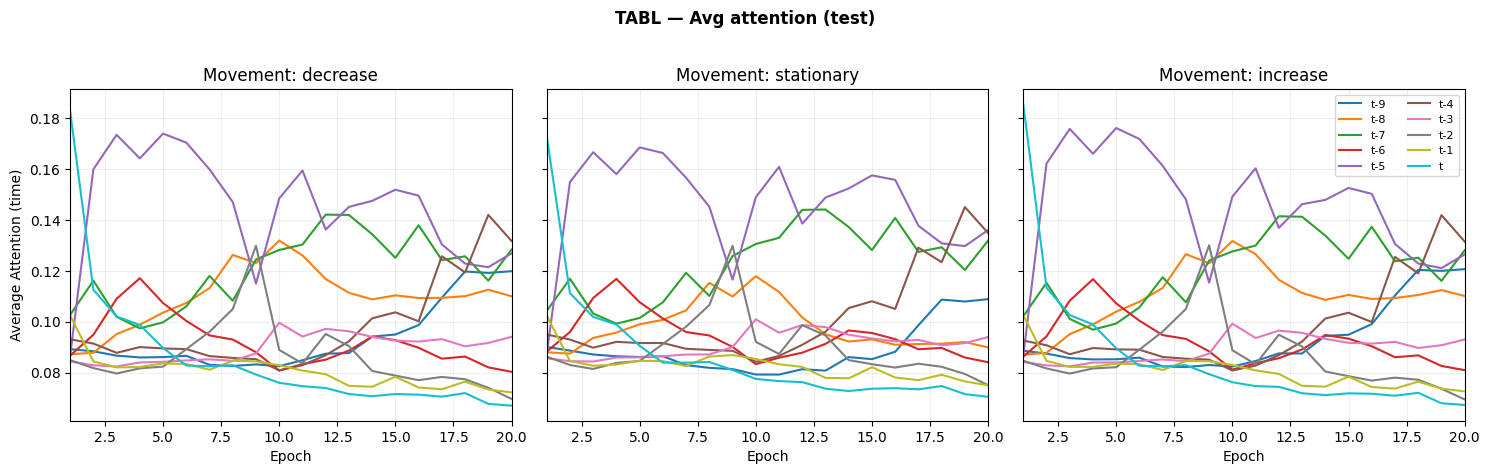

Fold 6 TEST | loss 0.4685 acc 0.8019 macroF1 0.7779

===== Fold 7: Train days 1..7 | Test day 8 =====
Epoch 001 | tr_loss 0.8586 acc 0.6290 | val_loss 0.6950 acc 0.7463 macroF1 0.6710
Epoch 002 | tr_loss 0.6572 acc 0.7560 | val_loss 0.5793 acc 0.7968 macroF1 0.7298
Epoch 003 | tr_loss 0.5927 acc 0.7808 | val_loss 0.5387 acc 0.8151 macroF1 0.7539
Epoch 004 | tr_loss 0.5601 acc 0.7906 | val_loss 0.5075 acc 0.8151 macroF1 0.7615
Epoch 005 | tr_loss 0.5373 acc 0.7956 | val_loss 0.4920 acc 0.8118 macroF1 0.7638
Epoch 006 | tr_loss 0.5221 acc 0.7993 | val_loss 0.4833 acc 0.8127 macroF1 0.7647
Epoch 007 | tr_loss 0.5084 acc 0.8029 | val_loss 0.4753 acc 0.8110 macroF1 0.7637
Epoch 008 | tr_loss 0.4997 acc 0.8032 | val_loss 0.4645 acc 0.8145 macroF1 0.7687
Epoch 009 | tr_loss 0.4912 acc 0.8043 | val_loss 0.4594 acc 0.8183 macroF1 0.7722
Epoch 010 | tr_loss 0.4865 acc 0.8054 | val_loss 0.4564 acc 0.8134 macroF1 0.7685
Epoch 011 | tr_loss 0.4828 acc 0.8062 | val_loss 0.4544 acc 0.8159 macroF1 0.7

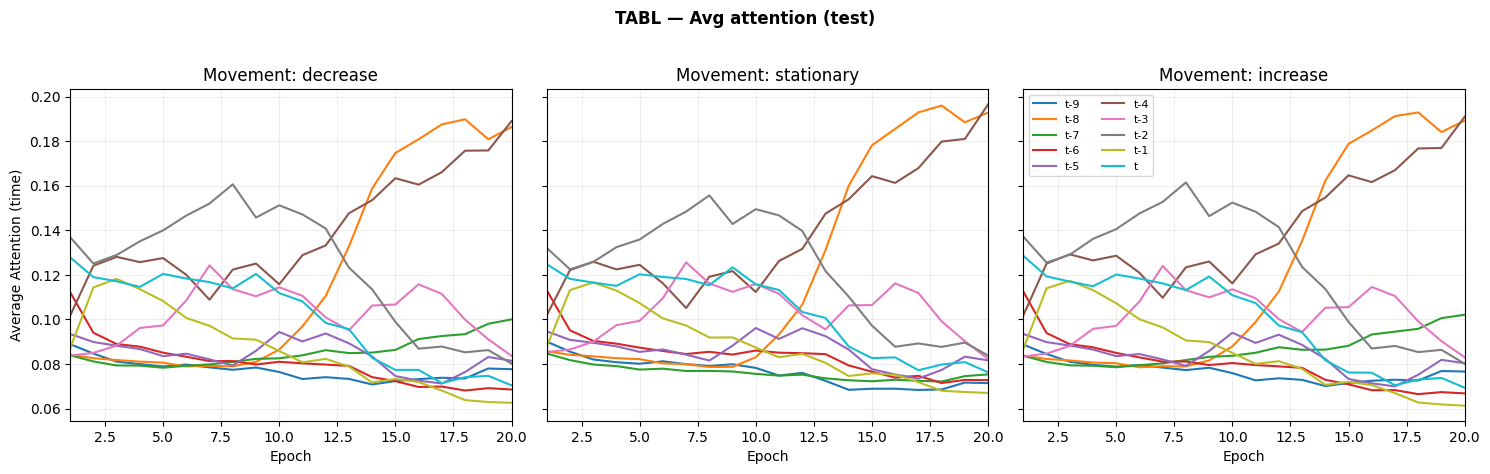

Fold 7 TEST | loss 0.3610 acc 0.8685 macroF1 0.7986

===== Fold 8: Train days 1..8 | Test day 9 =====
Epoch 001 | tr_loss 0.8644 acc 0.6249 | val_loss 0.6170 acc 0.7936 macroF1 0.6885
Epoch 002 | tr_loss 0.6348 acc 0.7656 | val_loss 0.4860 acc 0.8425 macroF1 0.7510
Epoch 003 | tr_loss 0.5716 acc 0.7881 | val_loss 0.4531 acc 0.8498 macroF1 0.7726
Epoch 004 | tr_loss 0.5427 acc 0.7962 | val_loss 0.4361 acc 0.8521 macroF1 0.7791
Epoch 005 | tr_loss 0.5239 acc 0.8015 | val_loss 0.4205 acc 0.8536 macroF1 0.7814
Epoch 006 | tr_loss 0.5114 acc 0.8041 | val_loss 0.4100 acc 0.8544 macroF1 0.7837
Epoch 007 | tr_loss 0.5022 acc 0.8059 | val_loss 0.4273 acc 0.8460 macroF1 0.7771
Epoch 008 | tr_loss 0.4931 acc 0.8066 | val_loss 0.3992 acc 0.8535 macroF1 0.7851
Epoch 009 | tr_loss 0.4873 acc 0.8077 | val_loss 0.3966 acc 0.8515 macroF1 0.7814
Epoch 010 | tr_loss 0.4809 acc 0.8093 | val_loss 0.3946 acc 0.8519 macroF1 0.7840
Epoch 011 | tr_loss 0.4764 acc 0.8094 | val_loss 0.3942 acc 0.8516 macroF1 0.7

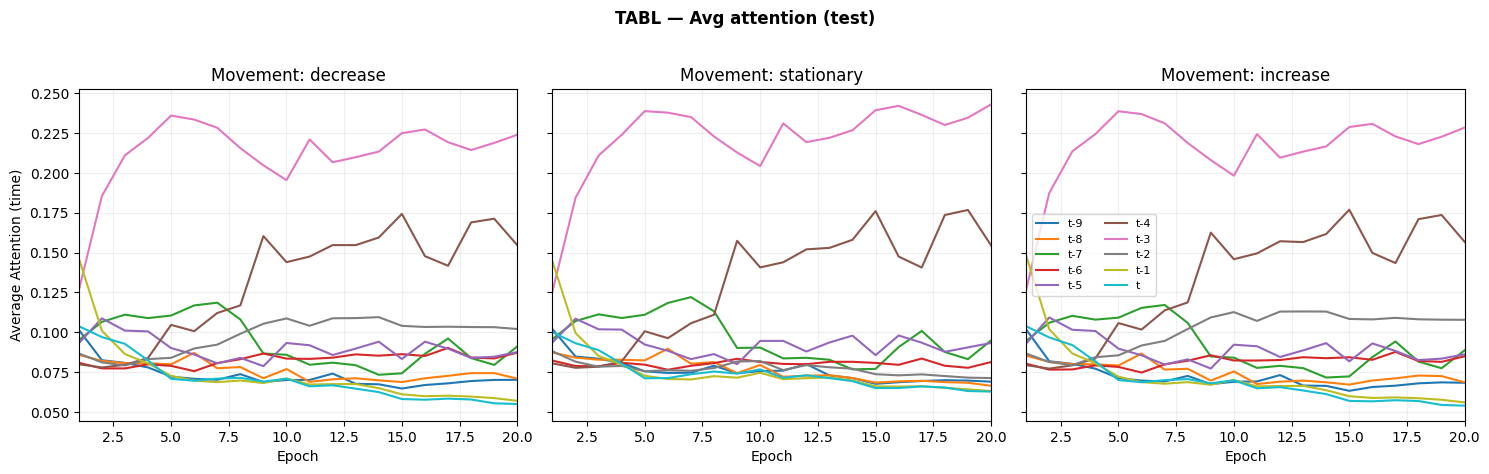

Fold 8 TEST | loss 0.3917 acc 0.8501 macroF1 0.7910

===== Fold 9: Train days 1..9 | Test day 10 =====
Epoch 001 | tr_loss 0.8131 acc 0.6505 | val_loss 0.5729 acc 0.8298 macroF1 0.7158
Epoch 002 | tr_loss 0.6067 acc 0.7818 | val_loss 0.4708 acc 0.8589 macroF1 0.7641
Epoch 003 | tr_loss 0.5539 acc 0.7977 | val_loss 0.4183 acc 0.8718 macroF1 0.7840
Epoch 004 | tr_loss 0.5294 acc 0.8043 | val_loss 0.4069 acc 0.8687 macroF1 0.7865
Epoch 005 | tr_loss 0.5120 acc 0.8086 | val_loss 0.3850 acc 0.8697 macroF1 0.7883
Epoch 006 | tr_loss 0.4977 acc 0.8107 | val_loss 0.3999 acc 0.8645 macroF1 0.7839
Epoch 007 | tr_loss 0.4897 acc 0.8122 | val_loss 0.3824 acc 0.8656 macroF1 0.7863
Epoch 008 | tr_loss 0.4824 acc 0.8125 | val_loss 0.3664 acc 0.8669 macroF1 0.7878
Epoch 009 | tr_loss 0.4731 acc 0.8149 | val_loss 0.3592 acc 0.8682 macroF1 0.7911
Epoch 010 | tr_loss 0.4669 acc 0.8161 | val_loss 0.3556 acc 0.8669 macroF1 0.7900
Epoch 011 | tr_loss 0.4623 acc 0.8160 | val_loss 0.3634 acc 0.8650 macroF1 0.

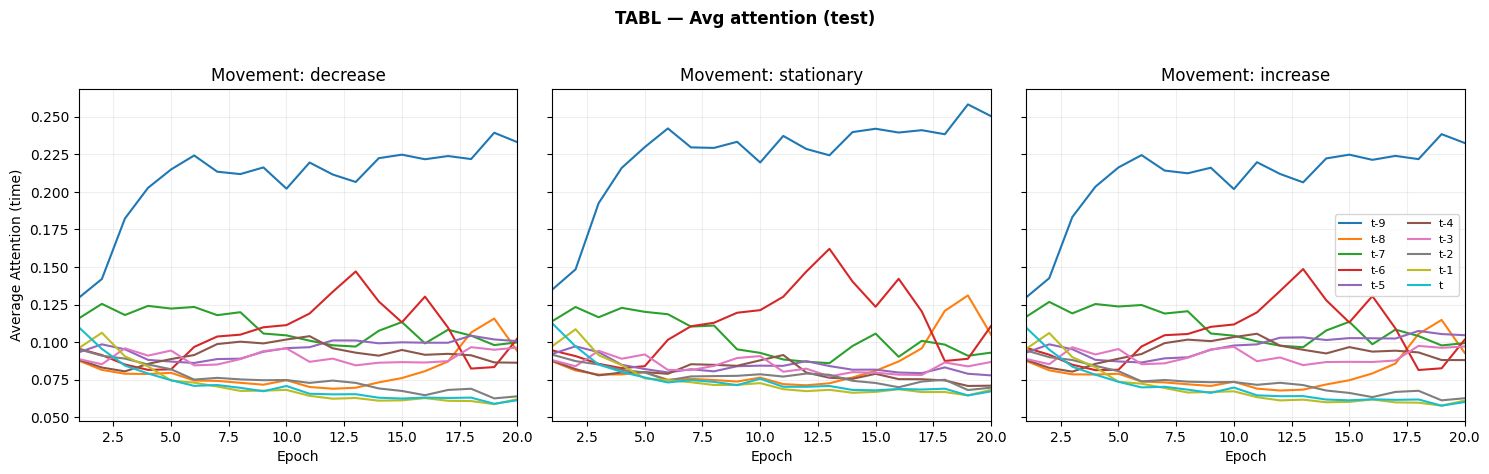

Fold 9 TEST | loss 0.4177 acc 0.8356 macroF1 0.7886

===== WALK-FORWARD SUMMARY: TABL =====
Test Acc    mean=0.8104 std=0.0352
Test MacroF1 mean=0.7666 std=0.0288


In [64]:
tabl_results = run_walk_forward_cv(
    model_builder=lambda: TABLClassifier(num_classes=3, in_dim=144, in_time=10, hidden_dim=64, hidden_time=5),
    model_name="TABL",
    val_ratio=0.1,
    track_attention=True,
    attention_every=1,
    attention_on="test",
    attention_collector=collect_avg_tabl_attention_per_class,
    plot_attention=True,
    plot_attention_title="TABL — Avg attention (test)"
)



MODEL (Setup1 walk-forward): TLOB (dual-attn + BiN + sinusoidal PE)


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.6311 acc 0.7320 | val_loss 0.5978 acc 0.7758 macroF1 0.7474
Epoch 002 | tr_loss 0.4620 acc 0.8143 | val_loss 0.5516 acc 0.8052 macroF1 0.7766
Epoch 003 | tr_loss 0.4126 acc 0.8244 | val_loss 0.5138 acc 0.7948 macroF1 0.7709
Epoch 004 | tr_loss 0.3833 acc 0.8314 | val_loss 0.5611 acc 0.7963 macroF1 0.7690
Epoch 005 | tr_loss 0.3556 acc 0.8367 | val_loss 0.5589 acc 0.8045 macroF1 0.7771
Epoch 006 | tr_loss 0.3277 acc 0.8423 | val_loss 0.5003 acc 0.7733 macroF1 0.7537
Epoch 007 | tr_loss 0.3005 acc 0.8508 | val_loss 0.5418 acc 0.7880 macroF1 0.7631
Epoch 008 | tr_loss 0.2847 acc 0.8564 | val_loss 0.6306 acc 0.7908 macroF1 0.7633
Epoch 009 | tr_loss 0.2624 acc 0.8649 | val_loss 0.6320 acc 0.7910 macroF1 0.7602
Epoch 010 | tr_loss 0.2397 acc 0.8723 | val_loss 0.6779 acc 0.7999 macroF1 0.7721
Epoch 011 | tr_loss 0.2280 acc 0.8781 | val_loss 0.6938 acc 

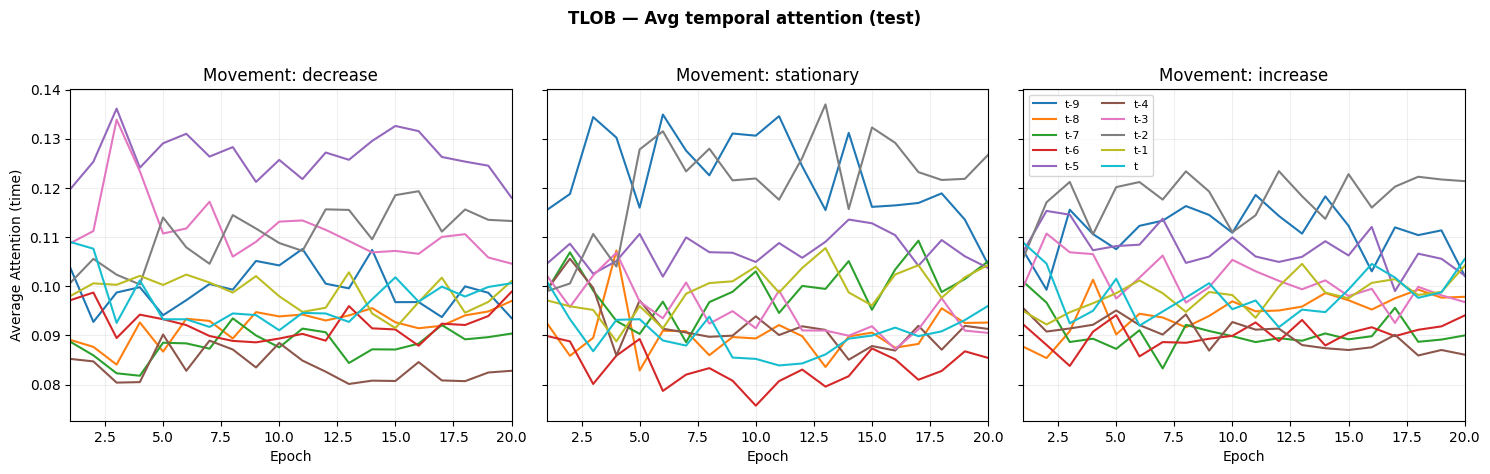

Fold 1 TEST | loss 0.4934 acc 0.8185 macroF1 0.7926

===== Fold 2: Train days 1..2 | Test day 3 =====
Epoch 001 | tr_loss 0.5913 acc 0.7519 | val_loss 0.4771 acc 0.8251 macroF1 0.7857
Epoch 002 | tr_loss 0.4539 acc 0.8133 | val_loss 0.4487 acc 0.7896 macroF1 0.7599
Epoch 003 | tr_loss 0.4186 acc 0.8174 | val_loss 0.4013 acc 0.8070 macroF1 0.7785
Epoch 004 | tr_loss 0.3958 acc 0.8216 | val_loss 0.3978 acc 0.8116 macroF1 0.7828
Epoch 005 | tr_loss 0.3750 acc 0.8245 | val_loss 0.3893 acc 0.8165 macroF1 0.7890
Epoch 006 | tr_loss 0.3580 acc 0.8277 | val_loss 0.3987 acc 0.8144 macroF1 0.7870
Epoch 007 | tr_loss 0.3398 acc 0.8322 | val_loss 0.4116 acc 0.8106 macroF1 0.7811
Epoch 008 | tr_loss 0.3215 acc 0.8386 | val_loss 0.4461 acc 0.8112 macroF1 0.7786
Epoch 009 | tr_loss 0.3063 acc 0.8430 | val_loss 0.4524 acc 0.8168 macroF1 0.7867
Epoch 010 | tr_loss 0.2892 acc 0.8480 | val_loss 0.4640 acc 0.8102 macroF1 0.7795
Epoch 011 | tr_loss 0.2738 acc 0.8530 | val_loss 0.5094 acc 0.8232 macroF1 0.7

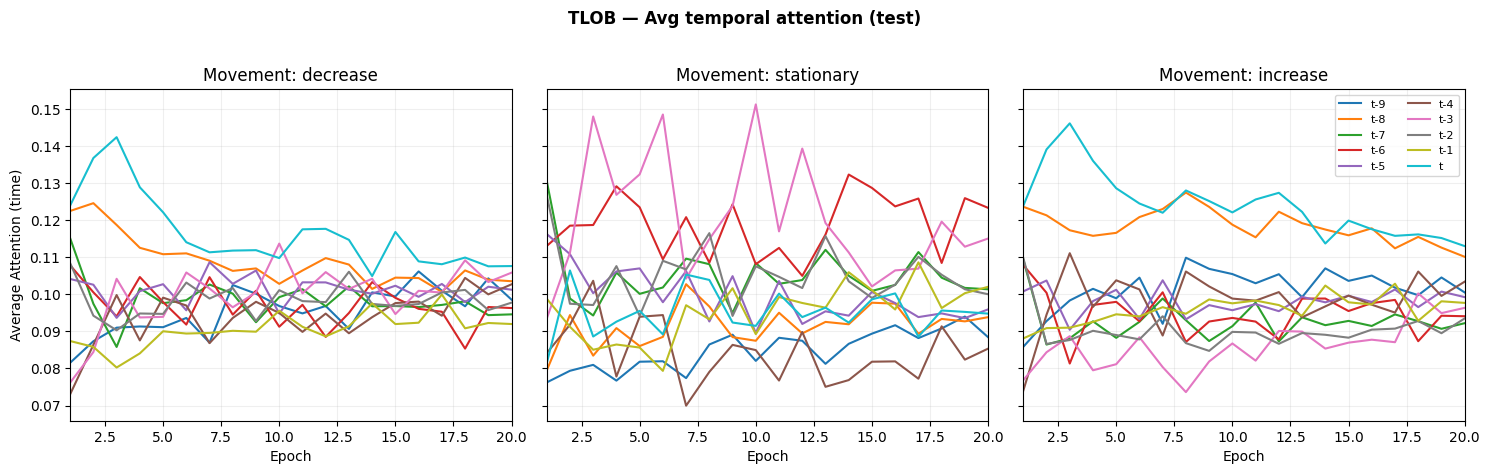

Fold 2 TEST | loss 0.6340 acc 0.8367 macroF1 0.7983

===== Fold 3: Train days 1..3 | Test day 4 =====
Epoch 001 | tr_loss 0.5416 acc 0.7742 | val_loss 0.4294 acc 0.8353 macroF1 0.7879
Epoch 002 | tr_loss 0.4332 acc 0.8132 | val_loss 0.3765 acc 0.8367 macroF1 0.7936
Epoch 003 | tr_loss 0.4055 acc 0.8172 | val_loss 0.3673 acc 0.8381 macroF1 0.7962
Epoch 004 | tr_loss 0.3873 acc 0.8201 | val_loss 0.3738 acc 0.8387 macroF1 0.7965
Epoch 005 | tr_loss 0.3732 acc 0.8229 | val_loss 0.3700 acc 0.8308 macroF1 0.7905
Epoch 006 | tr_loss 0.3590 acc 0.8242 | val_loss 0.3768 acc 0.8357 macroF1 0.7937
Epoch 007 | tr_loss 0.3456 acc 0.8278 | val_loss 0.3831 acc 0.8351 macroF1 0.7926
Epoch 008 | tr_loss 0.3319 acc 0.8326 | val_loss 0.3936 acc 0.8393 macroF1 0.7961
Epoch 009 | tr_loss 0.3177 acc 0.8367 | val_loss 0.4061 acc 0.8341 macroF1 0.7911
Epoch 010 | tr_loss 0.3060 acc 0.8389 | val_loss 0.4136 acc 0.8421 macroF1 0.7991
Epoch 011 | tr_loss 0.2924 acc 0.8430 | val_loss 0.4205 acc 0.8386 macroF1 0.7

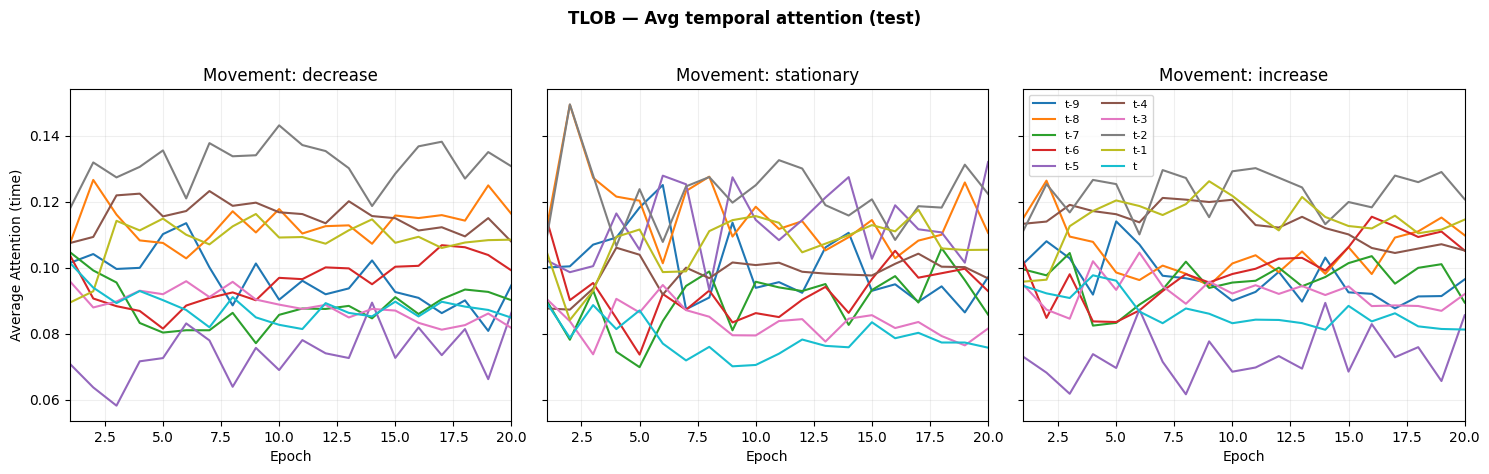

Fold 3 TEST | loss 0.4204 acc 0.8116 macroF1 0.7909

===== Fold 4: Train days 1..4 | Test day 5 =====
Epoch 001 | tr_loss 0.5150 acc 0.7842 | val_loss 0.4418 acc 0.8172 macroF1 0.7808
Epoch 002 | tr_loss 0.4142 acc 0.8164 | val_loss 0.3977 acc 0.8379 macroF1 0.8017
Epoch 003 | tr_loss 0.3940 acc 0.8208 | val_loss 0.3709 acc 0.8171 macroF1 0.7871
Epoch 004 | tr_loss 0.3774 acc 0.8221 | val_loss 0.3766 acc 0.8284 macroF1 0.7981
Epoch 005 | tr_loss 0.3681 acc 0.8231 | val_loss 0.3664 acc 0.8251 macroF1 0.7934
Epoch 006 | tr_loss 0.3547 acc 0.8258 | val_loss 0.3975 acc 0.8280 macroF1 0.7961
Epoch 007 | tr_loss 0.3444 acc 0.8279 | val_loss 0.3943 acc 0.8226 macroF1 0.7911
Epoch 008 | tr_loss 0.3325 acc 0.8302 | val_loss 0.4264 acc 0.8206 macroF1 0.7886
Epoch 009 | tr_loss 0.3205 acc 0.8341 | val_loss 0.4788 acc 0.8228 macroF1 0.7893
Epoch 010 | tr_loss 0.3099 acc 0.8374 | val_loss 0.4431 acc 0.8239 macroF1 0.7885
Epoch 011 | tr_loss 0.2983 acc 0.8424 | val_loss 0.5015 acc 0.8268 macroF1 0.7

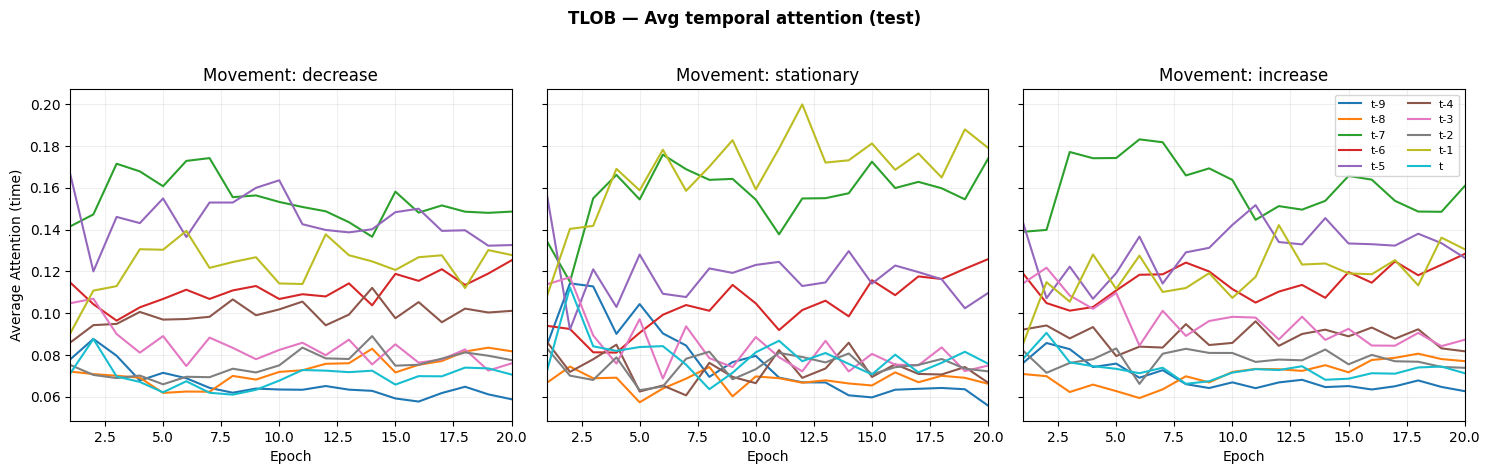

Fold 4 TEST | loss 0.4033 acc 0.8127 macroF1 0.7940

===== Fold 5: Train days 1..5 | Test day 6 =====
Epoch 001 | tr_loss 0.4934 acc 0.7932 | val_loss 0.4300 acc 0.8032 macroF1 0.7863
Epoch 002 | tr_loss 0.4054 acc 0.8170 | val_loss 0.4099 acc 0.7957 macroF1 0.7820
Epoch 003 | tr_loss 0.3894 acc 0.8177 | val_loss 0.4002 acc 0.7980 macroF1 0.7831
Epoch 004 | tr_loss 0.3754 acc 0.8198 | val_loss 0.3957 acc 0.7910 macroF1 0.7773
Epoch 005 | tr_loss 0.3675 acc 0.8217 | val_loss 0.3908 acc 0.7920 macroF1 0.7787
Epoch 006 | tr_loss 0.3588 acc 0.8224 | val_loss 0.4042 acc 0.8097 macroF1 0.7940
Epoch 007 | tr_loss 0.3479 acc 0.8251 | val_loss 0.4016 acc 0.7950 macroF1 0.7812
Epoch 008 | tr_loss 0.3404 acc 0.8274 | val_loss 0.3958 acc 0.7946 macroF1 0.7809
Epoch 009 | tr_loss 0.3295 acc 0.8312 | val_loss 0.4129 acc 0.8036 macroF1 0.7889
Epoch 010 | tr_loss 0.3200 acc 0.8333 | val_loss 0.4166 acc 0.8038 macroF1 0.7878
Epoch 011 | tr_loss 0.3095 acc 0.8358 | val_loss 0.4523 acc 0.8108 macroF1 0.7

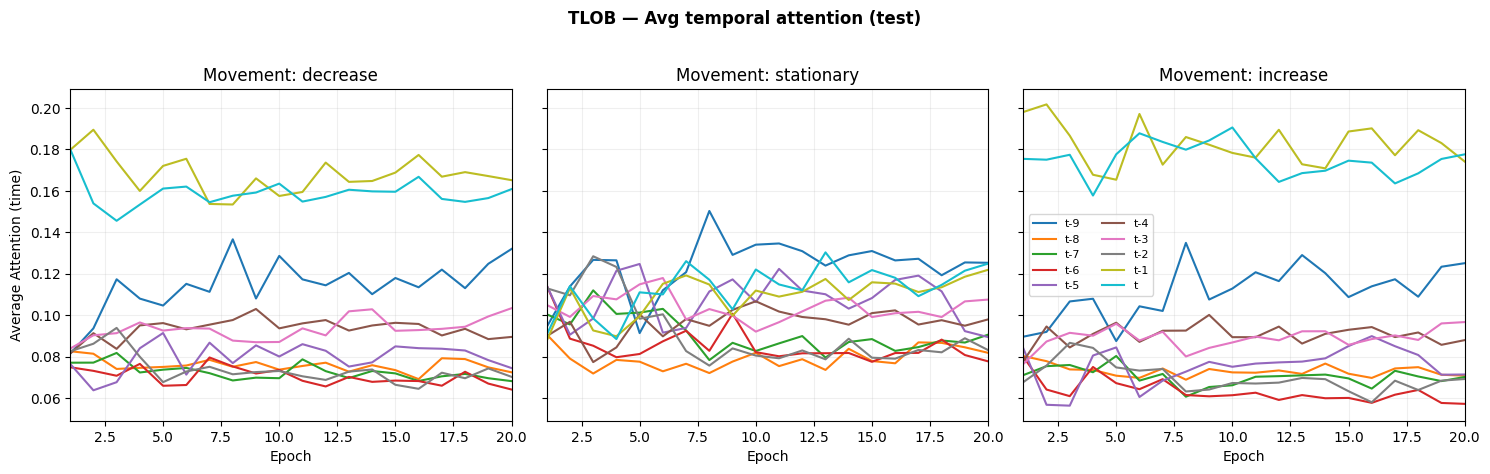

Fold 5 TEST | loss 0.3975 acc 0.8245 macroF1 0.8004

===== Fold 6: Train days 1..6 | Test day 7 =====
Epoch 001 | tr_loss 0.4849 acc 0.7913 | val_loss 0.4088 acc 0.8149 macroF1 0.7824
Epoch 002 | tr_loss 0.4006 acc 0.8165 | val_loss 0.3885 acc 0.8154 macroF1 0.7833
Epoch 003 | tr_loss 0.3834 acc 0.8180 | val_loss 0.3844 acc 0.8201 macroF1 0.7879
Epoch 004 | tr_loss 0.3731 acc 0.8188 | val_loss 0.3715 acc 0.8155 macroF1 0.7837
Epoch 005 | tr_loss 0.3657 acc 0.8190 | val_loss 0.3749 acc 0.8137 macroF1 0.7829
Epoch 006 | tr_loss 0.3562 acc 0.8214 | val_loss 0.3789 acc 0.8137 macroF1 0.7815
Epoch 007 | tr_loss 0.3493 acc 0.8227 | val_loss 0.3872 acc 0.8241 macroF1 0.7908
Epoch 008 | tr_loss 0.3416 acc 0.8250 | val_loss 0.3820 acc 0.8221 macroF1 0.7893
Epoch 009 | tr_loss 0.3352 acc 0.8255 | val_loss 0.3802 acc 0.8112 macroF1 0.7789
Epoch 010 | tr_loss 0.3285 acc 0.8270 | val_loss 0.3835 acc 0.8158 macroF1 0.7840
Epoch 011 | tr_loss 0.3216 acc 0.8295 | val_loss 0.4025 acc 0.8274 macroF1 0.7

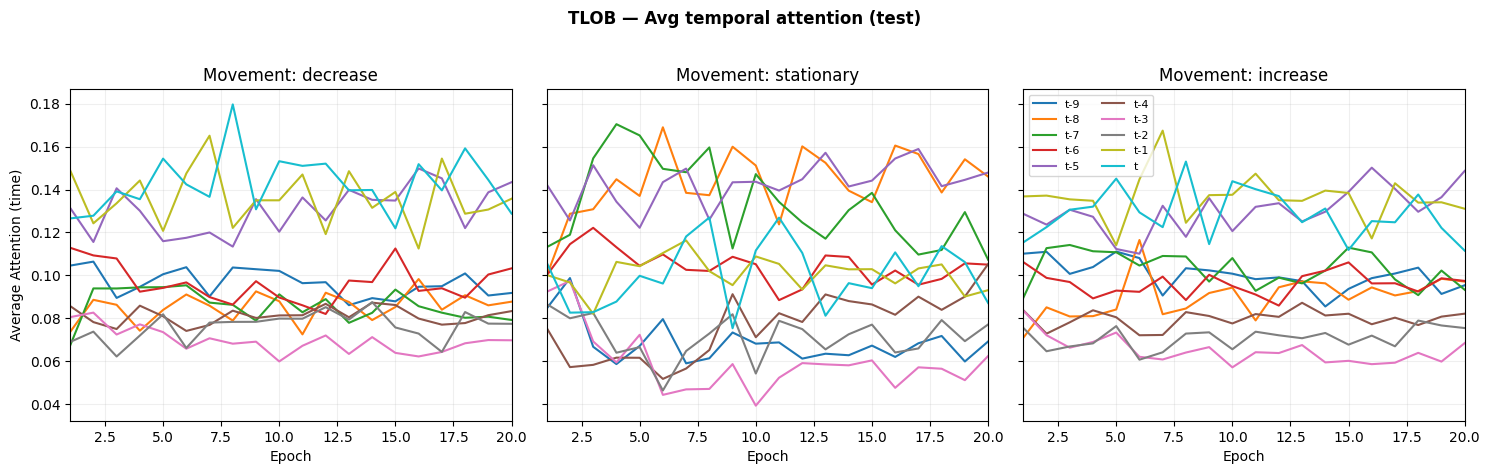

Fold 6 TEST | loss 0.4124 acc 0.8155 macroF1 0.7974

===== Fold 7: Train days 1..7 | Test day 8 =====
Epoch 001 | tr_loss 0.4784 acc 0.7954 | val_loss 0.3879 acc 0.8306 macroF1 0.7954
Epoch 002 | tr_loss 0.4035 acc 0.8138 | val_loss 0.3658 acc 0.8256 macroF1 0.7919
Epoch 003 | tr_loss 0.3870 acc 0.8147 | val_loss 0.3644 acc 0.8277 macroF1 0.7942
Epoch 004 | tr_loss 0.3766 acc 0.8173 | val_loss 0.3626 acc 0.8276 macroF1 0.7940
Epoch 005 | tr_loss 0.3676 acc 0.8185 | val_loss 0.3765 acc 0.8314 macroF1 0.7971
Epoch 006 | tr_loss 0.3601 acc 0.8205 | val_loss 0.3676 acc 0.8270 macroF1 0.7937
Epoch 007 | tr_loss 0.3525 acc 0.8217 | val_loss 0.3697 acc 0.8261 macroF1 0.7915
Epoch 008 | tr_loss 0.3442 acc 0.8235 | val_loss 0.3659 acc 0.8370 macroF1 0.8008
Epoch 009 | tr_loss 0.3366 acc 0.8257 | val_loss 0.3800 acc 0.8370 macroF1 0.8018
Epoch 010 | tr_loss 0.3289 acc 0.8288 | val_loss 0.3699 acc 0.8255 macroF1 0.7918
Epoch 011 | tr_loss 0.3203 acc 0.8307 | val_loss 0.3787 acc 0.8318 macroF1 0.7

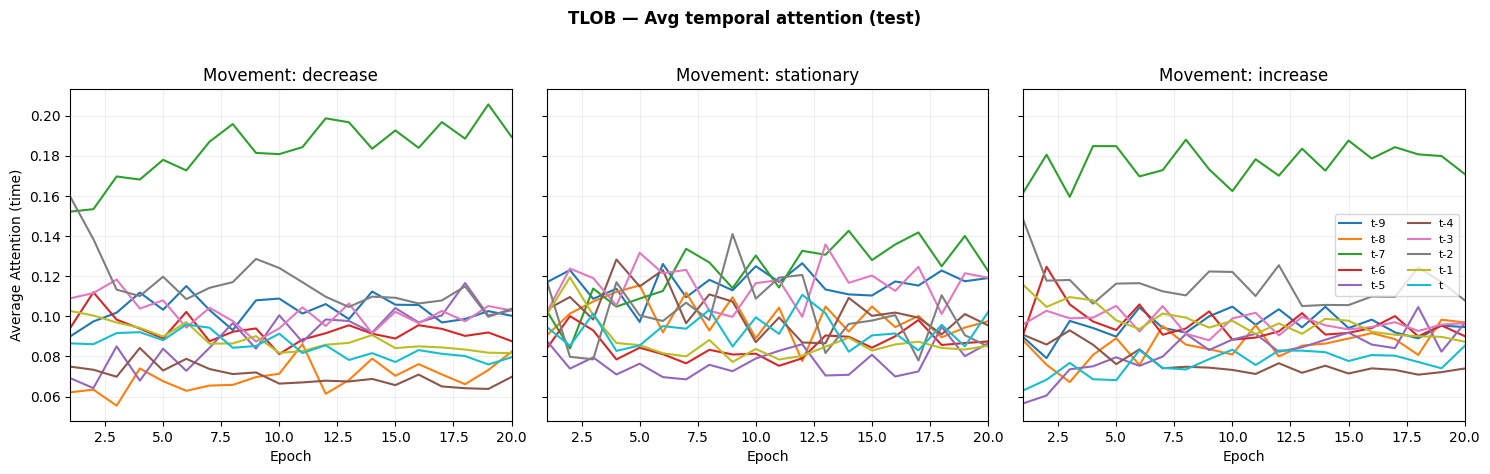

Fold 7 TEST | loss 0.2910 acc 0.8765 macroF1 0.8180

===== Fold 8: Train days 1..8 | Test day 9 =====
Epoch 001 | tr_loss 0.4591 acc 0.8043 | val_loss 0.3293 acc 0.8533 macroF1 0.7958
Epoch 002 | tr_loss 0.3870 acc 0.8195 | val_loss 0.3066 acc 0.8540 macroF1 0.7979
Epoch 003 | tr_loss 0.3715 acc 0.8209 | val_loss 0.3119 acc 0.8532 macroF1 0.7978
Epoch 004 | tr_loss 0.3622 acc 0.8221 | val_loss 0.2968 acc 0.8578 macroF1 0.8032
Epoch 005 | tr_loss 0.3539 acc 0.8245 | val_loss 0.2991 acc 0.8559 macroF1 0.8008
Epoch 006 | tr_loss 0.3467 acc 0.8253 | val_loss 0.2939 acc 0.8590 macroF1 0.8047
Epoch 007 | tr_loss 0.3395 acc 0.8271 | val_loss 0.2980 acc 0.8633 macroF1 0.8072
Epoch 008 | tr_loss 0.3325 acc 0.8280 | val_loss 0.3025 acc 0.8573 macroF1 0.8008
Epoch 009 | tr_loss 0.3248 acc 0.8299 | val_loss 0.3009 acc 0.8606 macroF1 0.8061
Epoch 010 | tr_loss 0.3170 acc 0.8320 | val_loss 0.3061 acc 0.8548 macroF1 0.8002
Epoch 011 | tr_loss 0.3099 acc 0.8339 | val_loss 0.3063 acc 0.8653 macroF1 0.8

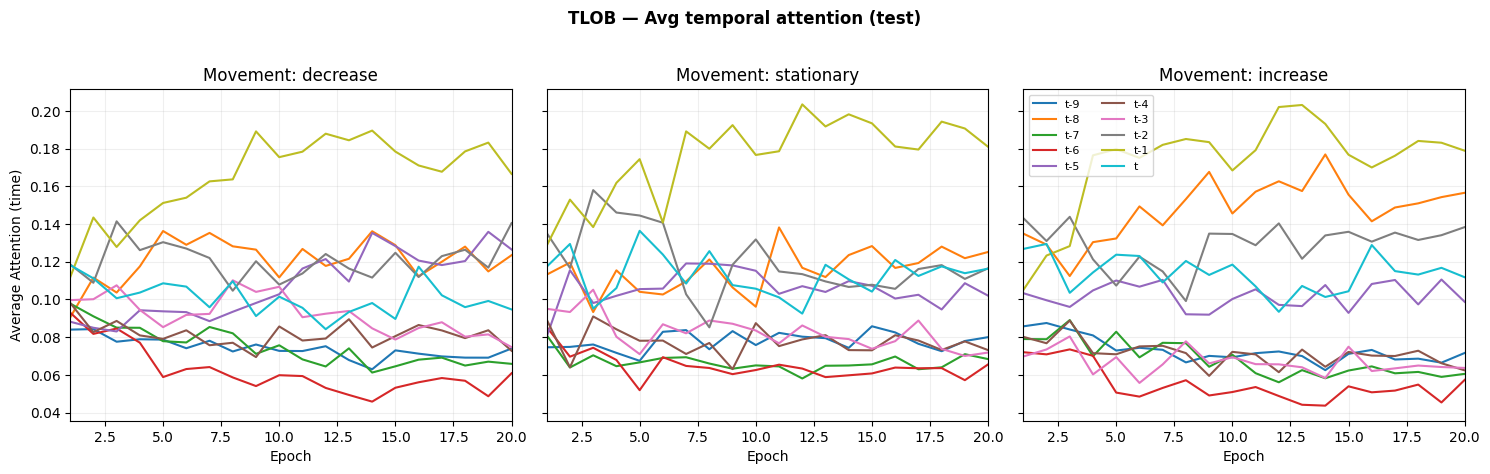

Fold 8 TEST | loss 0.3257 acc 0.8597 macroF1 0.8102

===== Fold 9: Train days 1..9 | Test day 10 =====
Epoch 001 | tr_loss 0.4449 acc 0.8096 | val_loss 0.3232 acc 0.8527 macroF1 0.7837
Epoch 002 | tr_loss 0.3822 acc 0.8230 | val_loss 0.2927 acc 0.8806 macroF1 0.8127
Epoch 003 | tr_loss 0.3668 acc 0.8248 | val_loss 0.2843 acc 0.8666 macroF1 0.7994
Epoch 004 | tr_loss 0.3577 acc 0.8261 | val_loss 0.2876 acc 0.8605 macroF1 0.7946
Epoch 005 | tr_loss 0.3495 acc 0.8267 | val_loss 0.2820 acc 0.8638 macroF1 0.8000
Epoch 006 | tr_loss 0.3437 acc 0.8282 | val_loss 0.2924 acc 0.8594 macroF1 0.7935
Epoch 007 | tr_loss 0.3381 acc 0.8286 | val_loss 0.2745 acc 0.8688 macroF1 0.8047
Epoch 008 | tr_loss 0.3305 acc 0.8303 | val_loss 0.2754 acc 0.8738 macroF1 0.8096
Epoch 009 | tr_loss 0.3254 acc 0.8314 | val_loss 0.2769 acc 0.8729 macroF1 0.8091
Epoch 010 | tr_loss 0.3184 acc 0.8330 | val_loss 0.2859 acc 0.8783 macroF1 0.8121
Epoch 011 | tr_loss 0.3114 acc 0.8342 | val_loss 0.2894 acc 0.8752 macroF1 0.

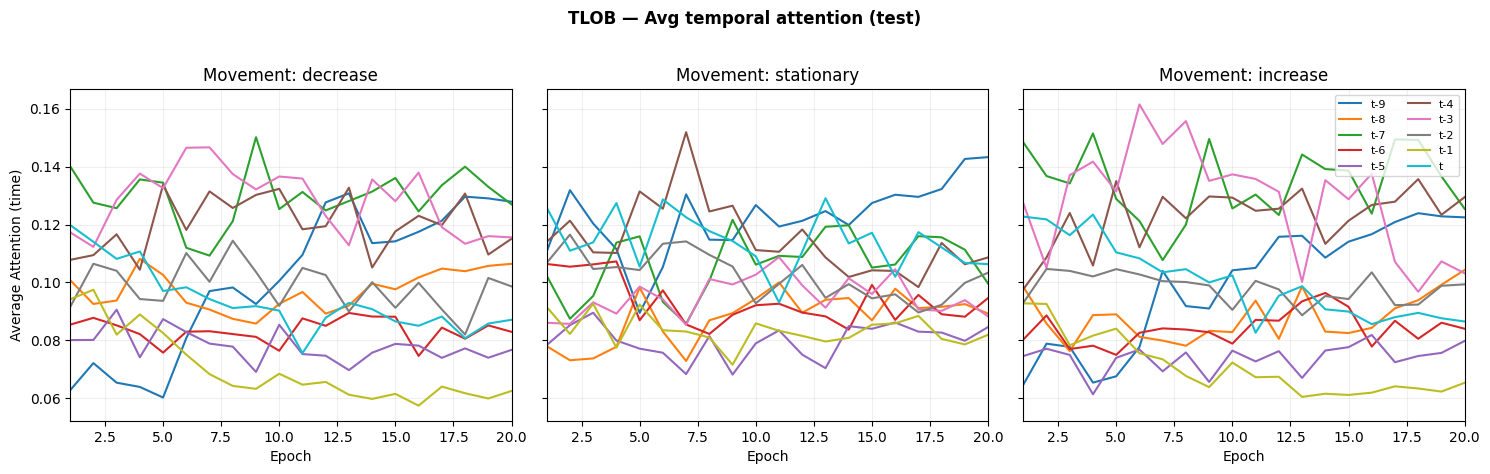

Fold 9 TEST | loss 0.3576 acc 0.8508 macroF1 0.8122

===== WALK-FORWARD SUMMARY: TLOB (dual-attn + BiN + sinusoidal PE) =====
Test Acc    mean=0.8341 std=0.0220
Test MacroF1 mean=0.8016 std=0.0091


In [ ]:
tlob_results = run_walk_forward_cv(
    model_builder=lambda: TLOBClassifier(
        num_classes=3,
        input_dim=144,
        time_steps=10,
        d_model=144,
        n_layers=2,
        n_heads_time=4,
        d_feat_attn=64,
        n_heads_feat=4,
        dropout=0.1,
        use_bin=True,
        use_pos_enc=True,
        cls_pool="last",
    ),

    model_name="TLOB",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1,
    track_attention=True,
    attention_on='test',
    attention_every=1,
    attention_collector=collect_avg_time_attention_per_class,
    plot_attention=True,
    plot_attention_title="TLOB — Avg temporal attention (test)"
)

In [71]:
df_mlp, sum_mlp = summarize_cv(mlp_results, "MLP")
df_cnn, sum_cnn = summarize_cv(cnn_results, "CNN")
df_lstm, sum_lstm = summarize_cv(lstm_results, "LSTM")
df_tcn, sum_tcn = summarize_cv(tcn_results, "TCN")
df_tabl, sum_tabl = summarize_cv(tabl_results, "TABL")
df_tlob, sum_tlob = summarize_cv(tlob_results, "TLOB")


In [73]:
summary_df = pd.DataFrame([sum_mlp, sum_cnn, sum_lstm, sum_tcn, sum_tlob, sum_tabl]).sort_values("f1_mean", ascending=False)
summary_df


,model,acc_mean,acc_std,f1_mean,f1_std
4,TLOB,0.834058,0.022042,0.801550,0.009055
5,TABL,0.810386,0.035173,0.766639,0.028754
3,TCN,0.795736,0.055603,0.748400,0.048497
1,CNN,0.782846,0.051798,0.734288,0.043718
2,LSTM,0.754837,0.058733,0.702612,0.051119
0,MLP,0.756892,0.070609,0.697623,0.059215


In [74]:
results_dict = {
    "MLP": mlp_results,
    "CNN": cnn_results,
    "TCN": tcn_results,
    "LSTM": lstm_results,
    "TABL": tabl_results,
    "TLOB": tlob_results,
}


In [75]:
def set_modern_mpl_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.fancybox": True,
        "lines.linewidth": 2.2,
        "lines.markersize": 6,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

set_modern_mpl_style()

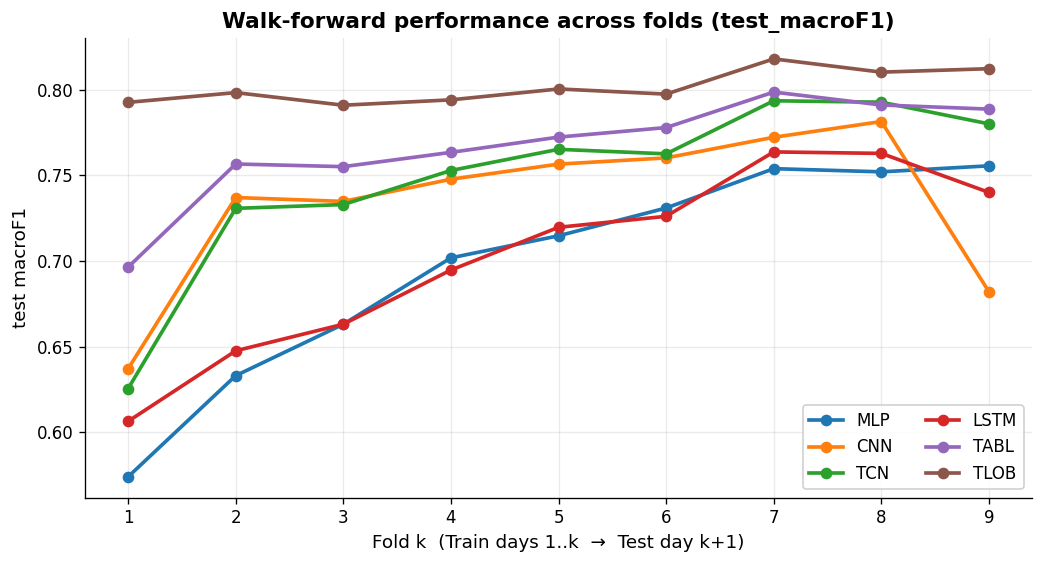

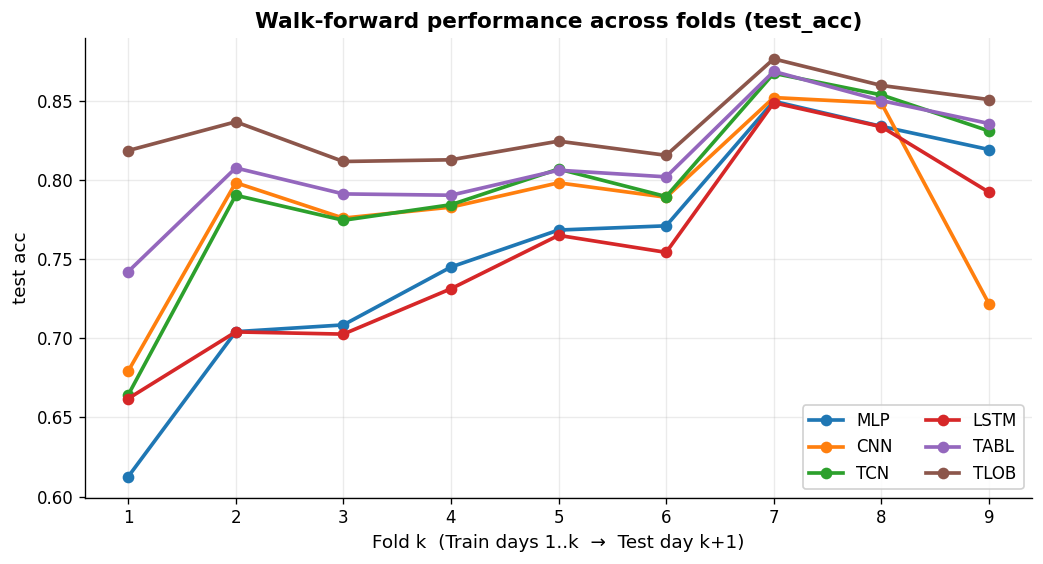

In [76]:
def plot_walk_forward(results_dict, metric="test_macroF1", title=None):
    plt.figure(figsize=(8.8, 4.8))
    
    for name, res in results_dict.items():
        folds = [r["fold"] for r in res]
        vals  = [r[metric] for r in res]
        plt.plot(folds, vals, marker="o", label=name) 

    plt.xticks(range(1, 10))
    plt.xlabel("Fold k  (Train days 1..k  →  Test day k+1)")
    plt.ylabel(metric.replace("_", " "))
    
    if title is None:
        title = f"Walk-forward performance across folds ({metric})"
    plt.title(title)
    
    plt.legend(ncol=2, loc="best")
    plt.tight_layout()
    plt.show()

plot_walk_forward(results_dict, metric="test_macroF1")
plot_walk_forward(results_dict, metric="test_acc")



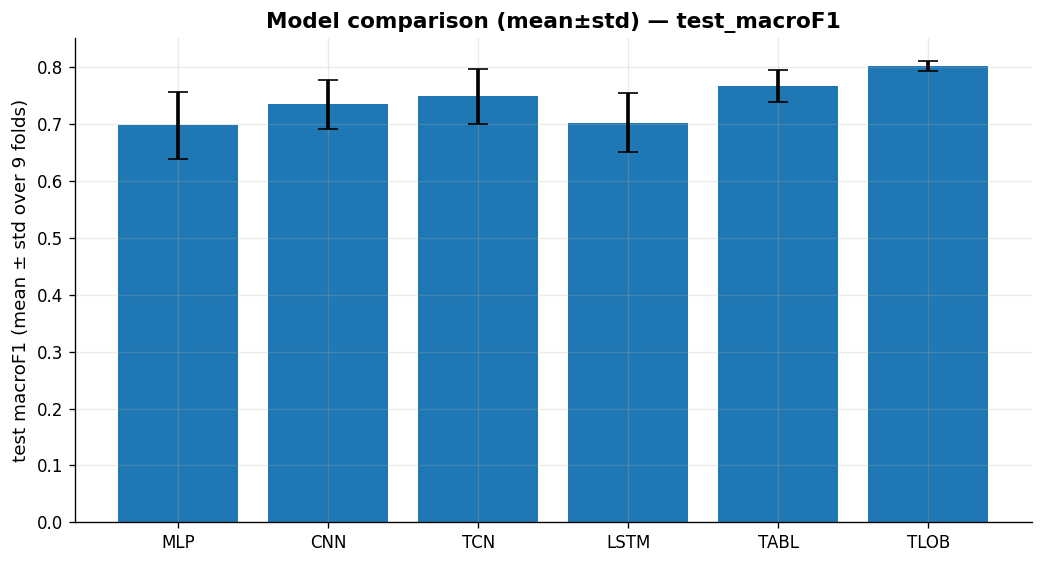

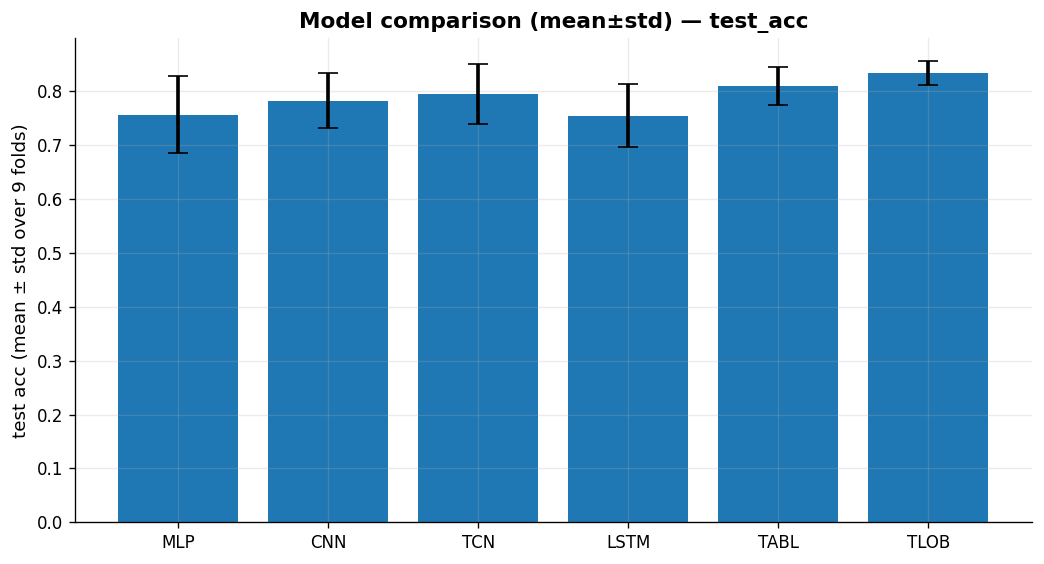

In [77]:
def bar_mean_std(results_dict, metric="test_macroF1", title=None):
    names = list(results_dict.keys())
    means = []
    stds  = []
    for name in names:
        vals = np.array([r[metric] for r in results_dict[name]])
        means.append(vals.mean())
        stds.append(vals.std(ddof=0))
    
    x = np.arange(len(names))
    plt.figure(figsize=(8.8, 4.8))
    plt.bar(x, means, yerr=stds, capsize=6)
    
    plt.xticks(x, names, rotation=0)
    plt.ylabel(f"{metric} (mean ± std over 9 folds)".replace("_", " "))
    
    if title is None:
        title = f"Model comparison (mean±std) — {metric}"
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

bar_mean_std(results_dict, metric="test_macroF1")
bar_mean_std(results_dict, metric="test_acc")



/tmp/ipykernel_52807/2106229668.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=names, showmeans=True)


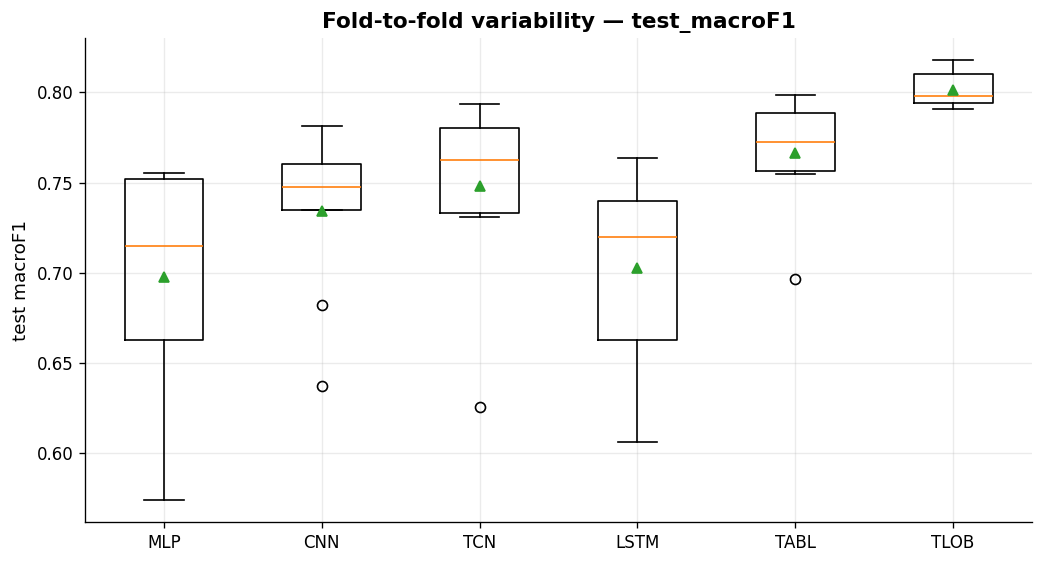

In [78]:
def boxplot_metric(results_dict, metric="test_macroF1", title=None):
    names = list(results_dict.keys())
    data = [ [r[metric] for r in results_dict[name]] for name in names ]
    
    plt.figure(figsize=(8.8, 4.8))
    plt.boxplot(data, labels=names, showmeans=True)
    plt.ylabel(metric.replace("_", " "))
    
    if title is None:
        title = f"Fold-to-fold variability — {metric}"
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

boxplot_metric(results_dict, metric="test_macroF1")

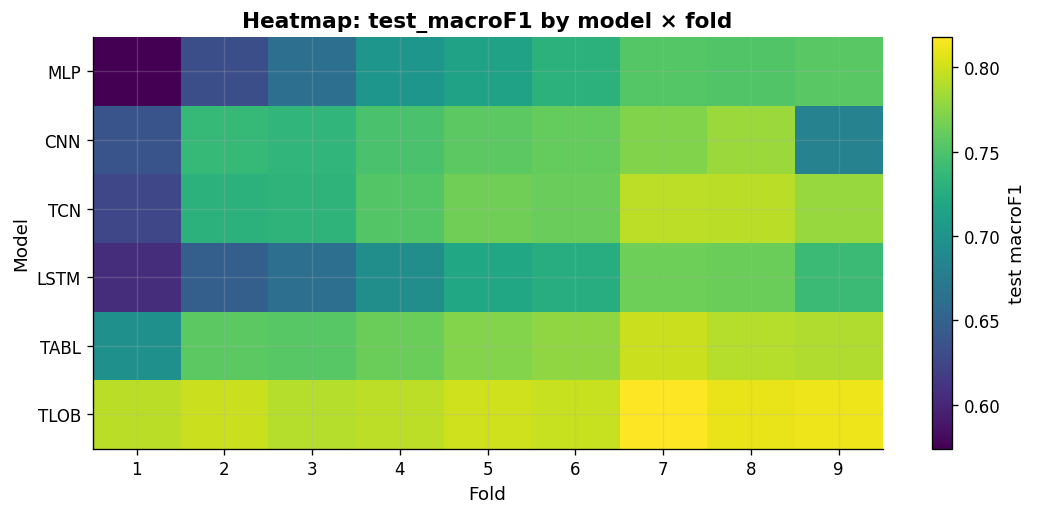

In [79]:
def heatmap_model_fold(results_dict, metric="test_macroF1", title=None):
    names = list(results_dict.keys())
    mat = np.array([[r[metric] for r in results_dict[name]] for name in names])  # (models, folds)
    
    plt.figure(figsize=(9.2, 4.4))
    im = plt.imshow(mat, aspect="auto")
    plt.colorbar(im, label=metric.replace("_", " "))
    
    plt.yticks(range(len(names)), names)
    plt.xticks(range(9), range(1, 10))
    plt.xlabel("Fold")
    plt.ylabel("Model")
    
    if title is None:
        title = f"Heatmap: {metric} by model × fold"
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

heatmap_model_fold(results_dict, metric="test_macroF1")

In [80]:
def plot_confusion_from_results(
    results,
    title,
    normalize,        
    annotate,
):
    y_true_all = np.concatenate([r["y_true"] for r in results])
    y_pred_all = np.concatenate([r["y_pred"] for r in results])

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, 2])

    if normalize is None:
        cm_show = cm.astype(float)
        cbar_label = "count"
        fmt = "d"
    elif normalize == "true":
        cm_show = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        cbar_label = "ratio (per true class)"
        fmt = ".2f"
    else:
        raise ValueError('normalize must be "true" or None')

    fig, ax = plt.subplots(figsize=(6.2, 5.4))


    if normalize == "true":
        im = ax.imshow(cm_show, cmap="YlGnBu", vmin=0.0, vmax=1.0, aspect="equal")
    else:
        im = ax.imshow(cm_show, cmap="YlGnBu", aspect="equal")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(["down", "stable", "up"])
    ax.set_yticklabels(["down", "stable", "up"])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 3, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)


    if annotate:

        thresh = (cm_show.max() + cm_show.min()) / 2.0 if cm_show.size else 0.5
        for i in range(3):
            for j in range(3):
                val = cm_show[i, j]
                if normalize is None:
                    text = format(int(val), fmt)
                else:
                    text = format(val, fmt)
                color = "white" if val > thresh else "black"
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=11)

    fig.tight_layout()
    plt.show()



Confusion matrix for model: MLP


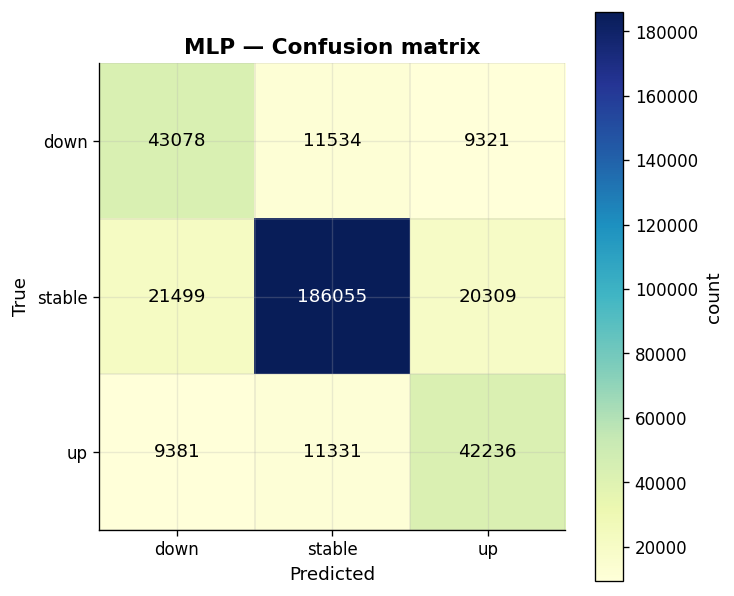

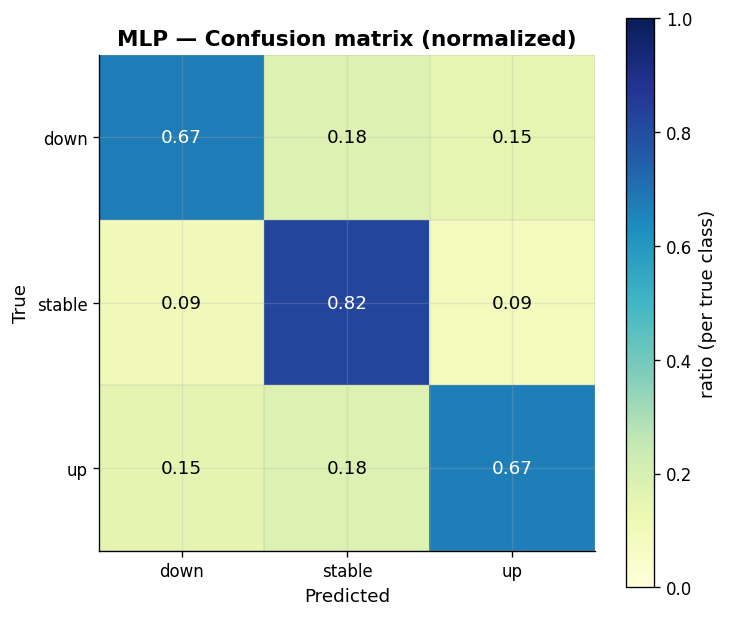


Confusion matrix for model: CNN


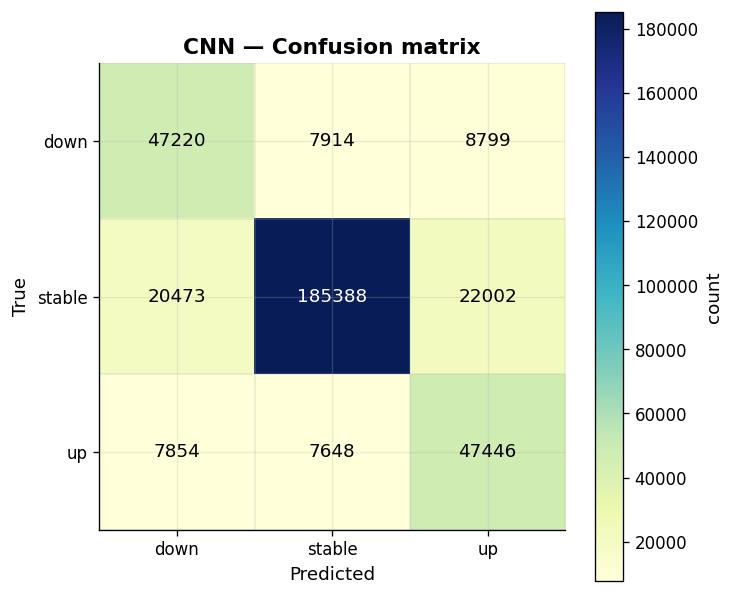

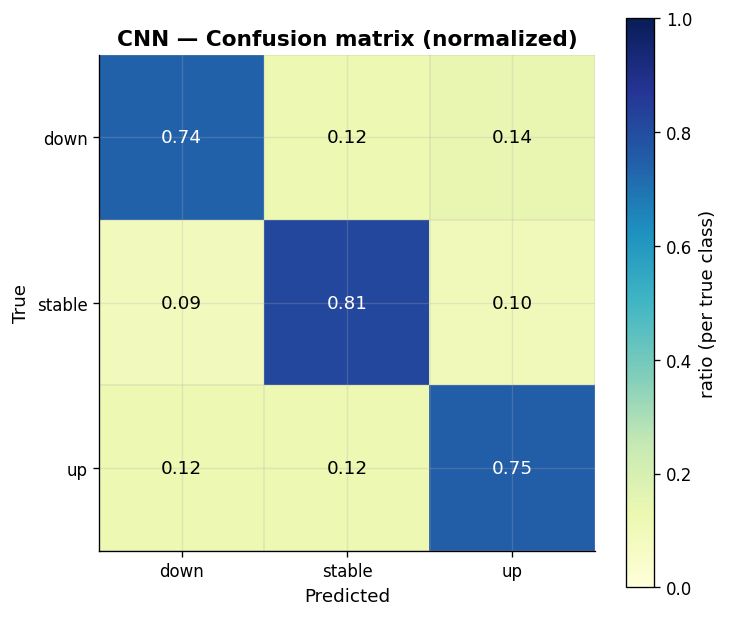


Confusion matrix for model: TCN


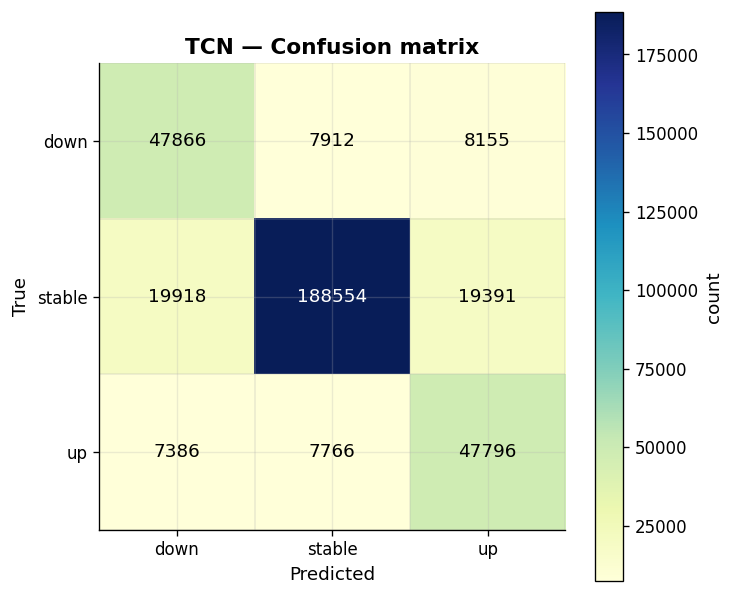

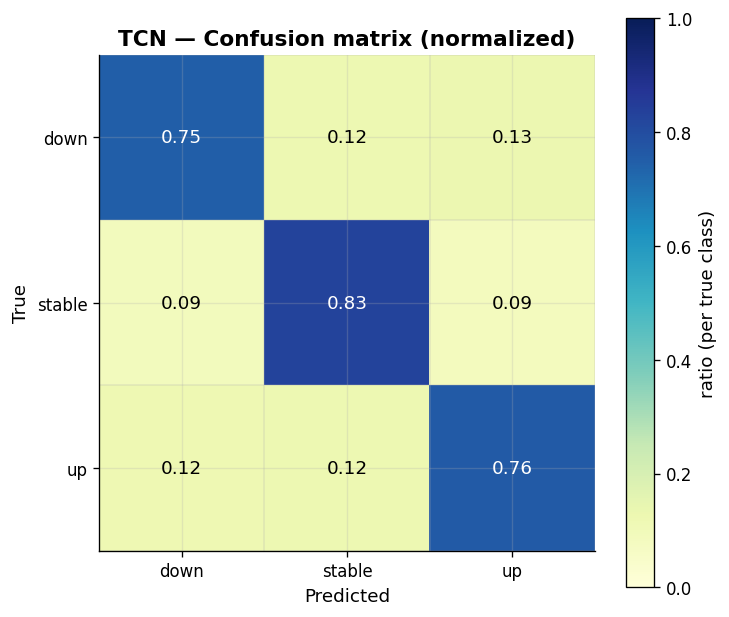


Confusion matrix for model: LSTM


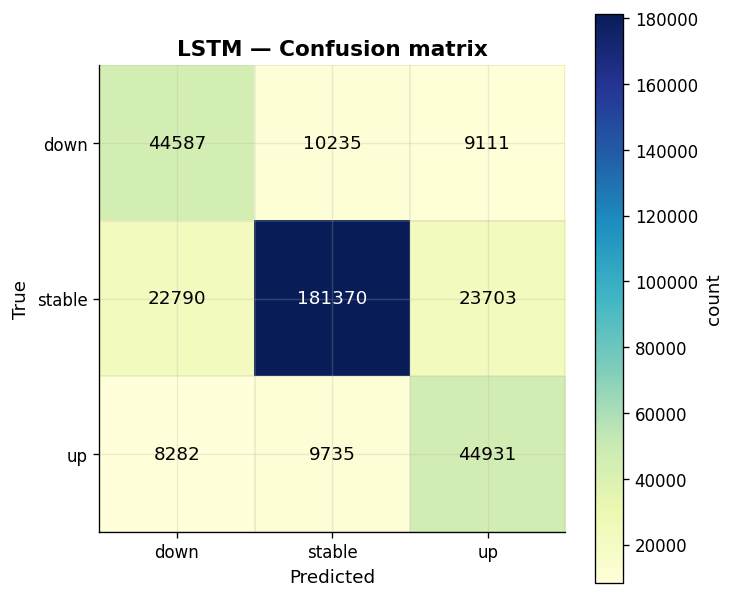

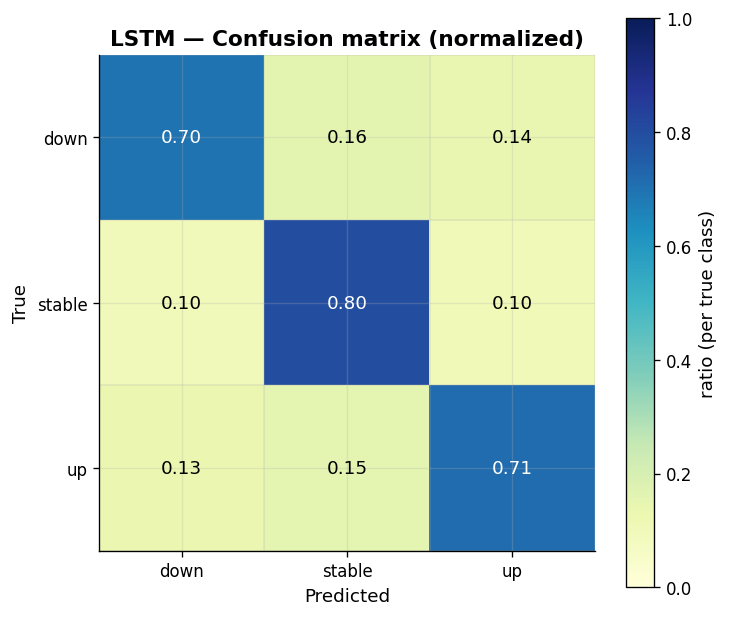


Confusion matrix for model: TABL


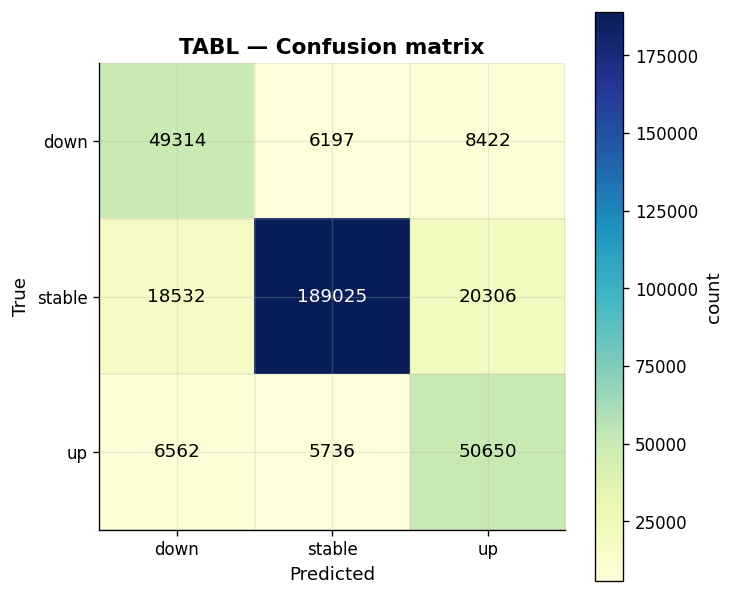

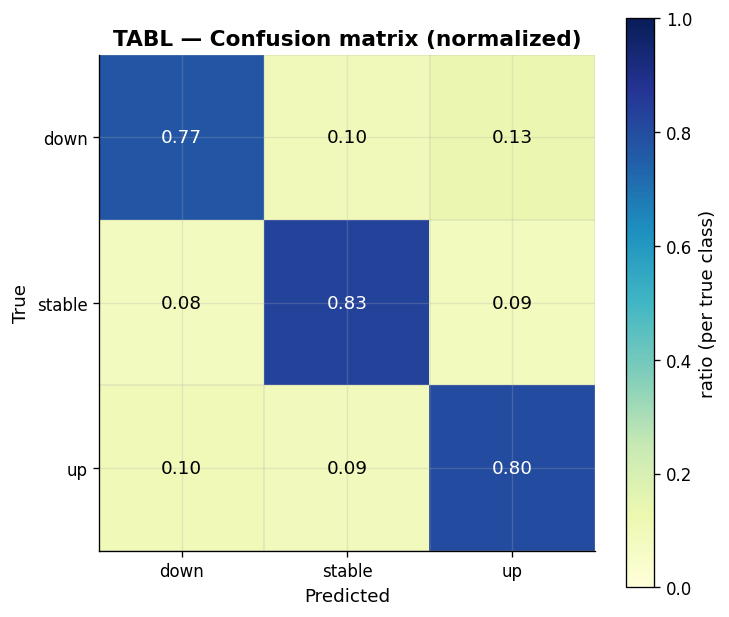


Confusion matrix for model: TLOB


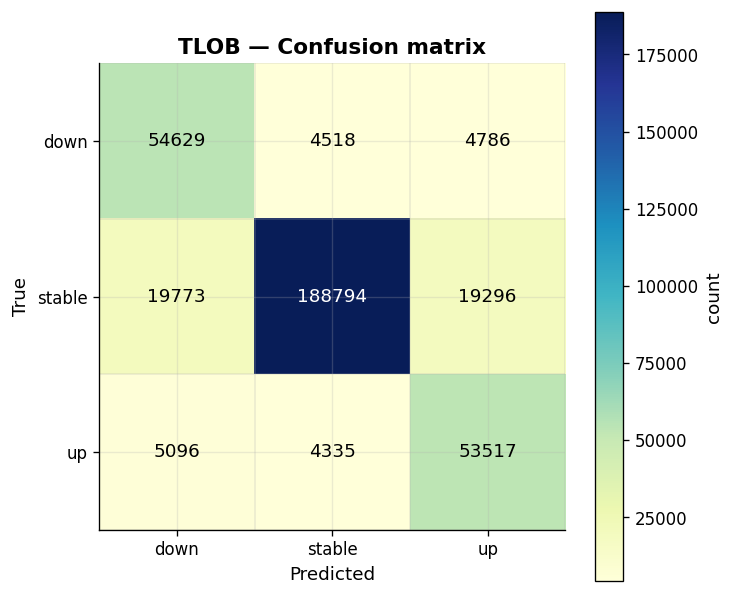

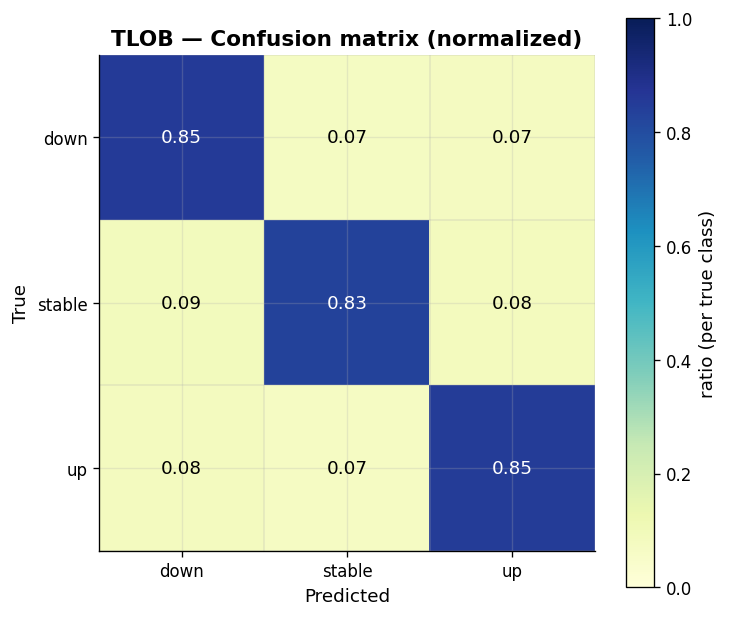

In [81]:
for i in results_dict.keys():
    print(f"\nConfusion matrix for model: {i}")
    plot_confusion_from_results(results_dict[i], title=f"{i} — Confusion matrix", normalize=None, annotate=True)
    plot_confusion_from_results(results_dict[i], title=f"{i} — Confusion matrix (normalized)", normalize="true", annotate=True)